In [39]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

plt.style.use('default')

## `Problem 1 to 5`:

Dataset link: https://tinyurl.com/2fe6vz4u

**Add a label to every axis and add a proper title for the charts. Also add proper labels if there are multiple representations.** Then, you can customize it as your wish.

### **`Problem-1:`** Draw a line plot of which, the x-axis is the "Year" and the y-axis is sum of "PM2.5" of two countries Iran and China.

In [69]:
# code here
df = pd.read_csv('https://tinyurl.com/2fe6vz4u')
df.drop(columns = "Unnamed: 0",inplace = True)
df.head()

,Position,Country,City/Town,Year,PM2.5,Temporal coverage,PM10,Temporal coverage.1,Database version (year)
0,1,India,Kanpur,2016,173,>75%,319,NaN,2018
1,2,India,Faridabad,2016,172,>75%,316,NaN,2018
2,3,India,Gaya,2016,149,50% -< 75%,275,NaN,2018
3,4,India,Varanasi,2016,146,>75%,260,NaN,2018
4,5,India,Patna,2016,144,>75%,266,NaN,2018


In [70]:
iran_china = df[df["Country"].isin(["Iran", "China"])]
pm25_by_year = iran_china.groupby(["Year", "Country"])["PM2.5"].sum().unstack()
pm25_by_year.index

Index([2012, 2013, 2014, 2015, 2016], dtype='int64', name='Year')

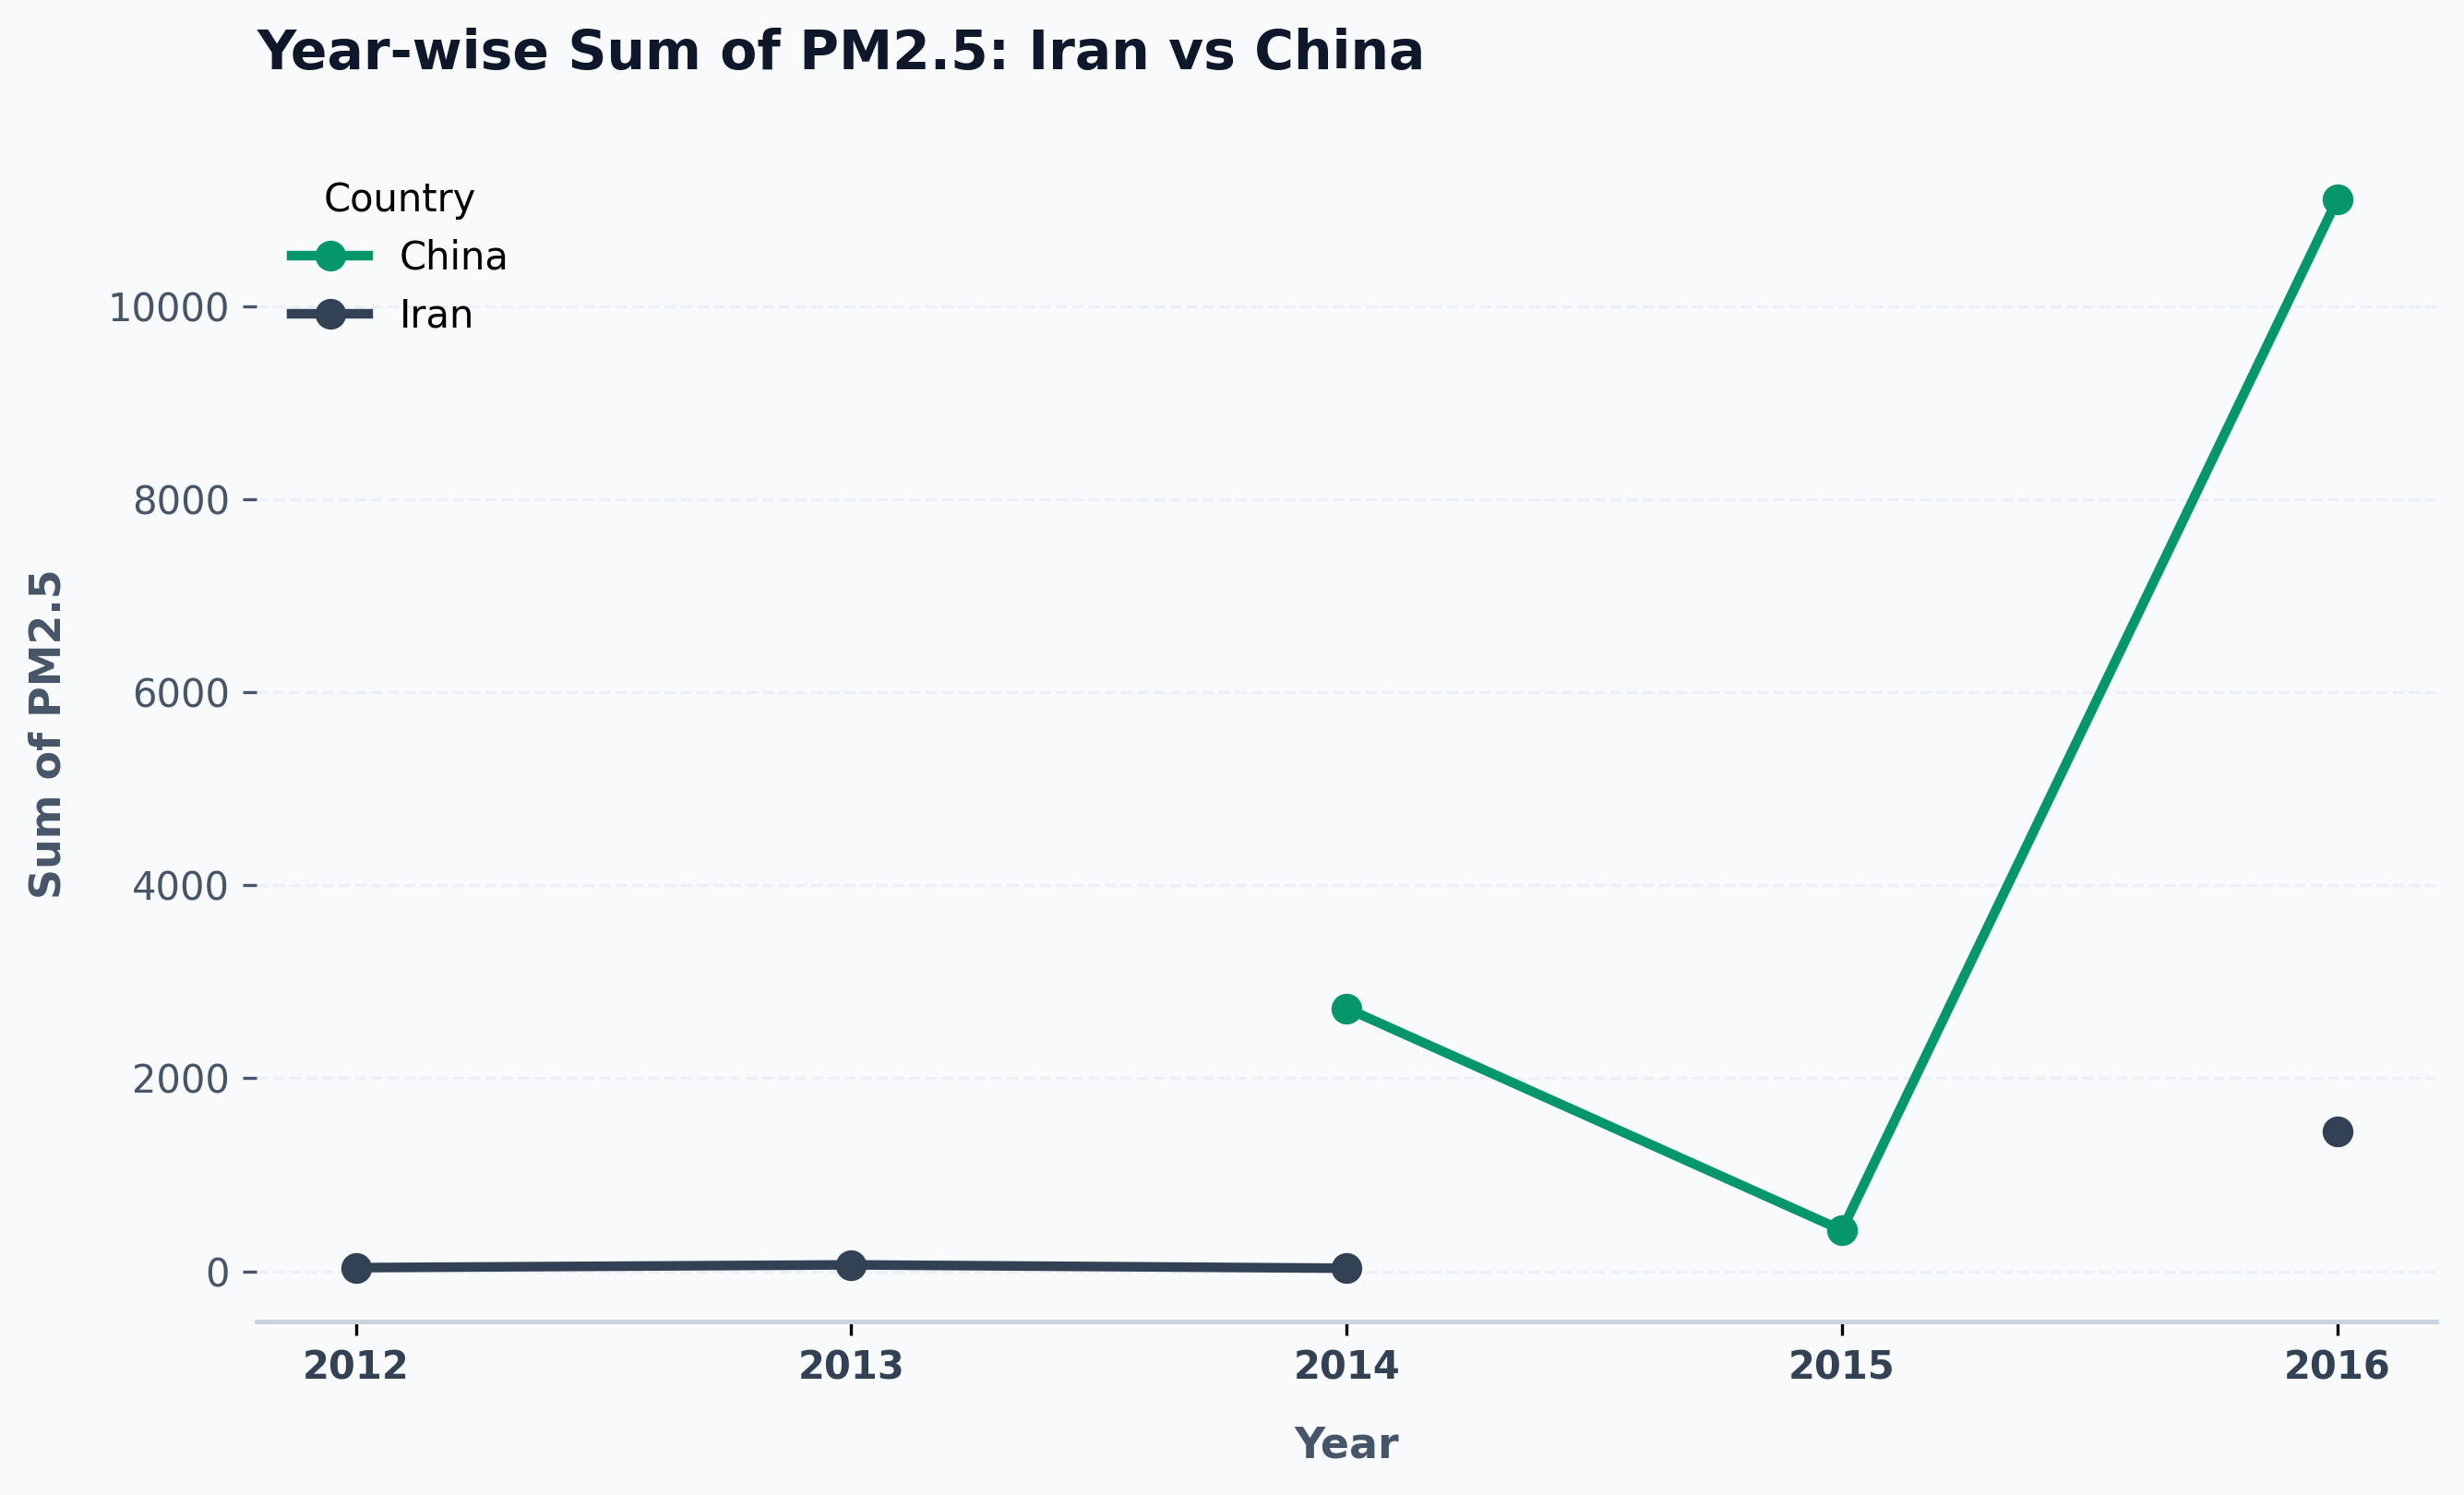

In [71]:
# Select only the rows where the country is either Iran or China.
# This allows us to compare the PM2.5 pollution levels of these two countries.
iran_china = df[df["Country"].isin(["Iran", "China"])]


# Group the filtered data by Year and Country.
# Then calculate the total PM2.5 value for each year and each country.
#
# After groupby and sum, the data looks like this:
#
# Year  Country
# 2010  China       500
#       Iran        300
# 2011  China       600
#       Iran        350
#
# unstack() moves the Country values into separate columns.
# This makes it easier to plot China and Iran as two separate lines.
pm25_by_year = (
    iran_china
    .groupby(["Year", "Country"])["PM2.5"]
    .sum()
    .unstack()
)


# Create the figure and the axes for the chart.
#
# figsize controls the width and height of the chart.
# dpi controls the resolution of the figure.
# A higher dpi gives a sharper image, especially when saving the chart.
fig, ax = plt.subplots(figsize=(9, 5.5), dpi=300)


# Set a light background color for the entire figure.
# This gives the chart a clean and professional appearance.
fig.patch.set_facecolor("#F8FAFC")


# Set the same background color for the actual plotting area.
ax.set_facecolor("#F8FAFC")


# Plot China's yearly PM2.5 values.
#
# pm25_by_year.index contains the years, which will be placed on the x-axis.
# pm25_by_year["China"] contains China's PM2.5 values, which will be placed on the y-axis.
# marker="o" adds a small circle at each year's data point.
# linewidth controls the thickness of the line.
# label is used later in the legend.
plt.plot(
    pm25_by_year.index,
    pm25_by_year["China"],
    marker="o",
    markersize=7,
    linewidth=2.5,
    color="#059669",
    label="China"
)


# Plot Iran's yearly PM2.5 values on the same chart.
# Using the same x-axis allows us to directly compare Iran with China.
plt.plot(
    pm25_by_year.index,
    pm25_by_year["Iran"],
    marker="o",
    markersize=7,
    linewidth=2.5,
    color="#334155",
    label="Iran"
)


# Convert the year values to integers.
# This helps keep the year labels clean and avoids unnecessary decimal values
# such as 2016.0 on the x-axis.
years = pm25_by_year.index.astype(int)


# Set the exact years that should appear on the x-axis.
# The same year values are used as both the tick positions and their labels.
#
# fontsize controls the text size.
# fontweight makes the year labels bold.
# color changes the color of the year labels.
plt.xticks(
    ticks=years,
    labels=years,
    fontsize=10,
    fontweight="bold",
    color="#334155"
)


# Display normal numbers on the y-axis instead of scientific notation.
#
# For example, instead of showing:
# 1e5
#
# the chart will show:
# 100000
#
# This makes the pollution values easier to read.
plt.ticklabel_format(style="plain", axis="y")


# Customize the appearance of the y-axis tick labels.
# This changes their color and size without changing the actual data.
ax.tick_params(
    axis="y",
    colors="#475569",
    labelsize=10
)


# Remove the top, right, and left borders of the chart.
# Removing unnecessary borders gives the chart a cleaner appearance.
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)


# Keep only the bottom border of the chart.
# This helps separate the x-axis from the plotting area.
ax.spines["bottom"].set_color("#CBD5E1")


# Make the bottom border slightly thicker so it remains visible.
ax.spines["bottom"].set_linewidth(1.2)


# Add a clear title to explain what the chart is showing.
# The title tells us that we are comparing the yearly total PM2.5
# values of Iran and China.
plt.title(
    "Year-wise Sum of PM2.5: Iran vs China",
    fontsize=14,
    fontweight="bold",
    color="#0F172A",
    pad=20,
    loc="left"
)


# Add a label to the x-axis.
# The x-axis represents the years in which the pollution data was recorded.
plt.xlabel(
    "Year",
    fontsize=11,
    fontweight="bold",
    color="#475569",
    labelpad=10
)


# Add a label to the y-axis.
# The y-axis represents the total PM2.5 value for each year.
plt.ylabel(
    "Sum of PM2.5",
    fontsize=11,
    fontweight="bold",
    color="#475569",
    labelpad=10
)


# Add horizontal grid lines to make it easier to compare the PM2.5 values
# across different years.
#
# axis="y" means that only horizontal grid lines will be shown.
# linestyle="--" creates dashed lines.
# alpha controls how transparent the grid lines are.
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5,
    color="#E2E8F0"
)


# Add a legend to identify which line belongs to each country.
# The legend title makes the purpose of the legend clear.
# frameon=False removes the box around the legend for a cleaner look.
plt.legend(
    title="Country",
    frameon=False,
    loc="upper left"
)


# Adjust the spacing around the chart automatically.
# This helps prevent titles and labels from being cut off.
plt.tight_layout()


# Save the final chart as a high-resolution PNG image.
#
# dpi=300 saves the chart in high quality.
# facecolor keeps the background color when saving the image.
# bbox_inches="tight" removes unnecessary extra space around the chart.
plt.savefig(
    "plots/problem1_iran_china.png",
    dpi=300,
    facecolor=fig.get_facecolor(),
    bbox_inches="tight"
)


# Display the chart in the notebook.
plt.show()

### **`Problem-2:`** Draw a histogram of the  column "PM10" of which the y-axis represents the probability (see the documentation how to draw the probability).

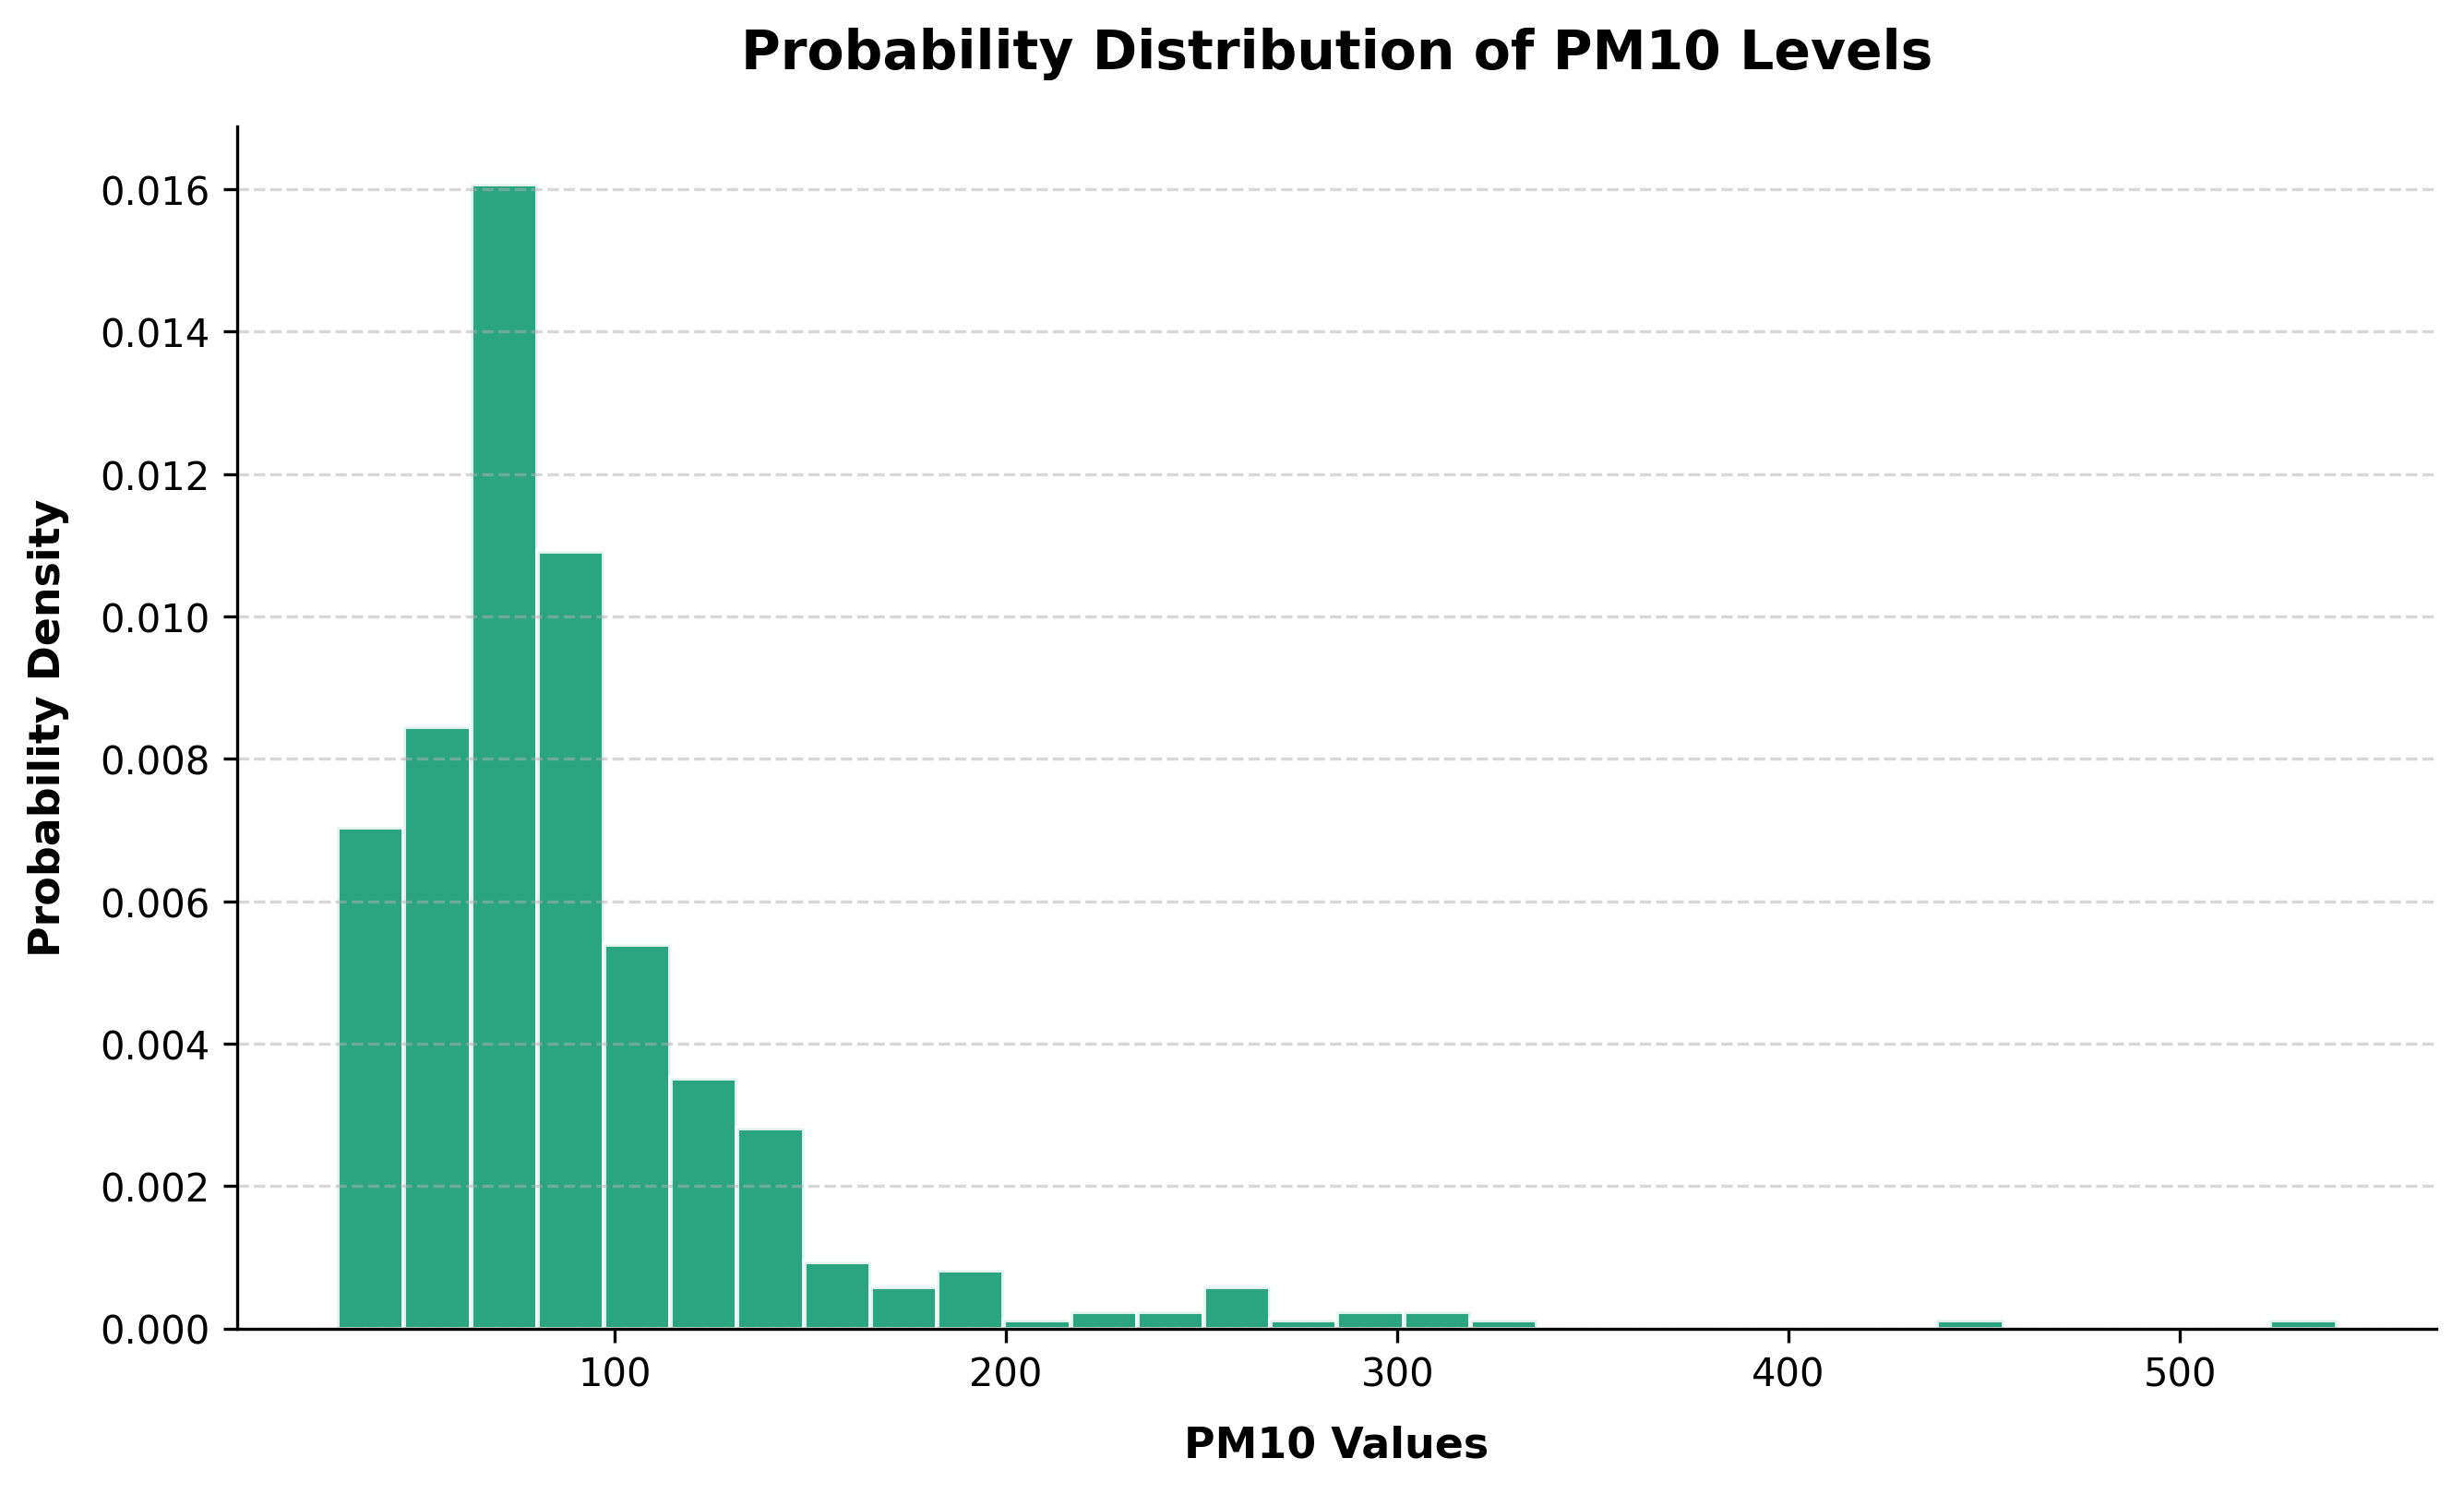

In [73]:
# Set the size and resolution of the figure.
#
# figsize controls the width and height of the chart.
# dpi=300 creates a high-resolution figure, which is useful when saving
# the chart for reports or presentations.
plt.figure(figsize=(9, 5.5), dpi=300)


# Create a histogram to see how PM10 values are distributed.
#
# dropna() removes missing PM10 values before creating the histogram.
# bins=30 divides the PM10 values into 30 intervals.
#
# density=True changes the y-axis from the number of observations
# to probability density.
#
# This means the histogram shows the shape of the distribution
# rather than simply showing how many rows fall into each interval.
plt.hist(
    df["PM10"].dropna(),
    bins=30,
    density=True,
    color="#059669",
    edgecolor="white",
    linewidth=1.2,
    alpha=0.85
)


# Use normal number formatting on the y-axis instead of scientific notation.
# This makes the values easier to read.
plt.ticklabel_format(
    style="plain",
    axis="y"
)


# Add a label to the x-axis.
# The x-axis represents the PM10 values in the dataset.
plt.xlabel(
    "PM10 Values",
    fontsize=11,
    fontweight="bold",
    labelpad=8
)


# Add a label to the y-axis.
# Because density=True was used, the y-axis represents probability density.
plt.ylabel(
    "Probability Density",
    fontsize=11,
    fontweight="bold",
    labelpad=8
)


# Add a clear title that explains what the histogram shows.
# The chart shows how PM10 values are distributed across the dataset.
plt.title(
    "Probability Distribution of PM10 Levels",
    fontsize=14,
    fontweight="bold",
    pad=15
)


# Add horizontal grid lines to make the height of each part of the histogram
# easier to compare.
#
# axis="y" means that only horizontal grid lines are displayed.
# Dashed lines keep the chart simple and easy to read.
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)


# Remove the top and right borders of the chart.
# This gives the histogram a cleaner and less crowded appearance.
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)


# Automatically adjust the spacing so that the title and labels
# do not overlap or get cut off.
plt.tight_layout()


# Save the histogram as a high-resolution PNG image.
#
# dpi=300 keeps the saved image sharp.
# bbox_inches="tight" removes unnecessary empty space around the chart.
plt.savefig(
    "plots/problem2_pm10_histogram.png",
    dpi=300,
    bbox_inches="tight"
)


# Display the histogram in the notebook.
plt.show()

### **`Problem-3:`** Draw a scatter plot where x-axis represents "PM2.5" and y-axis represents "PM10" for two countries Poland and Chile.

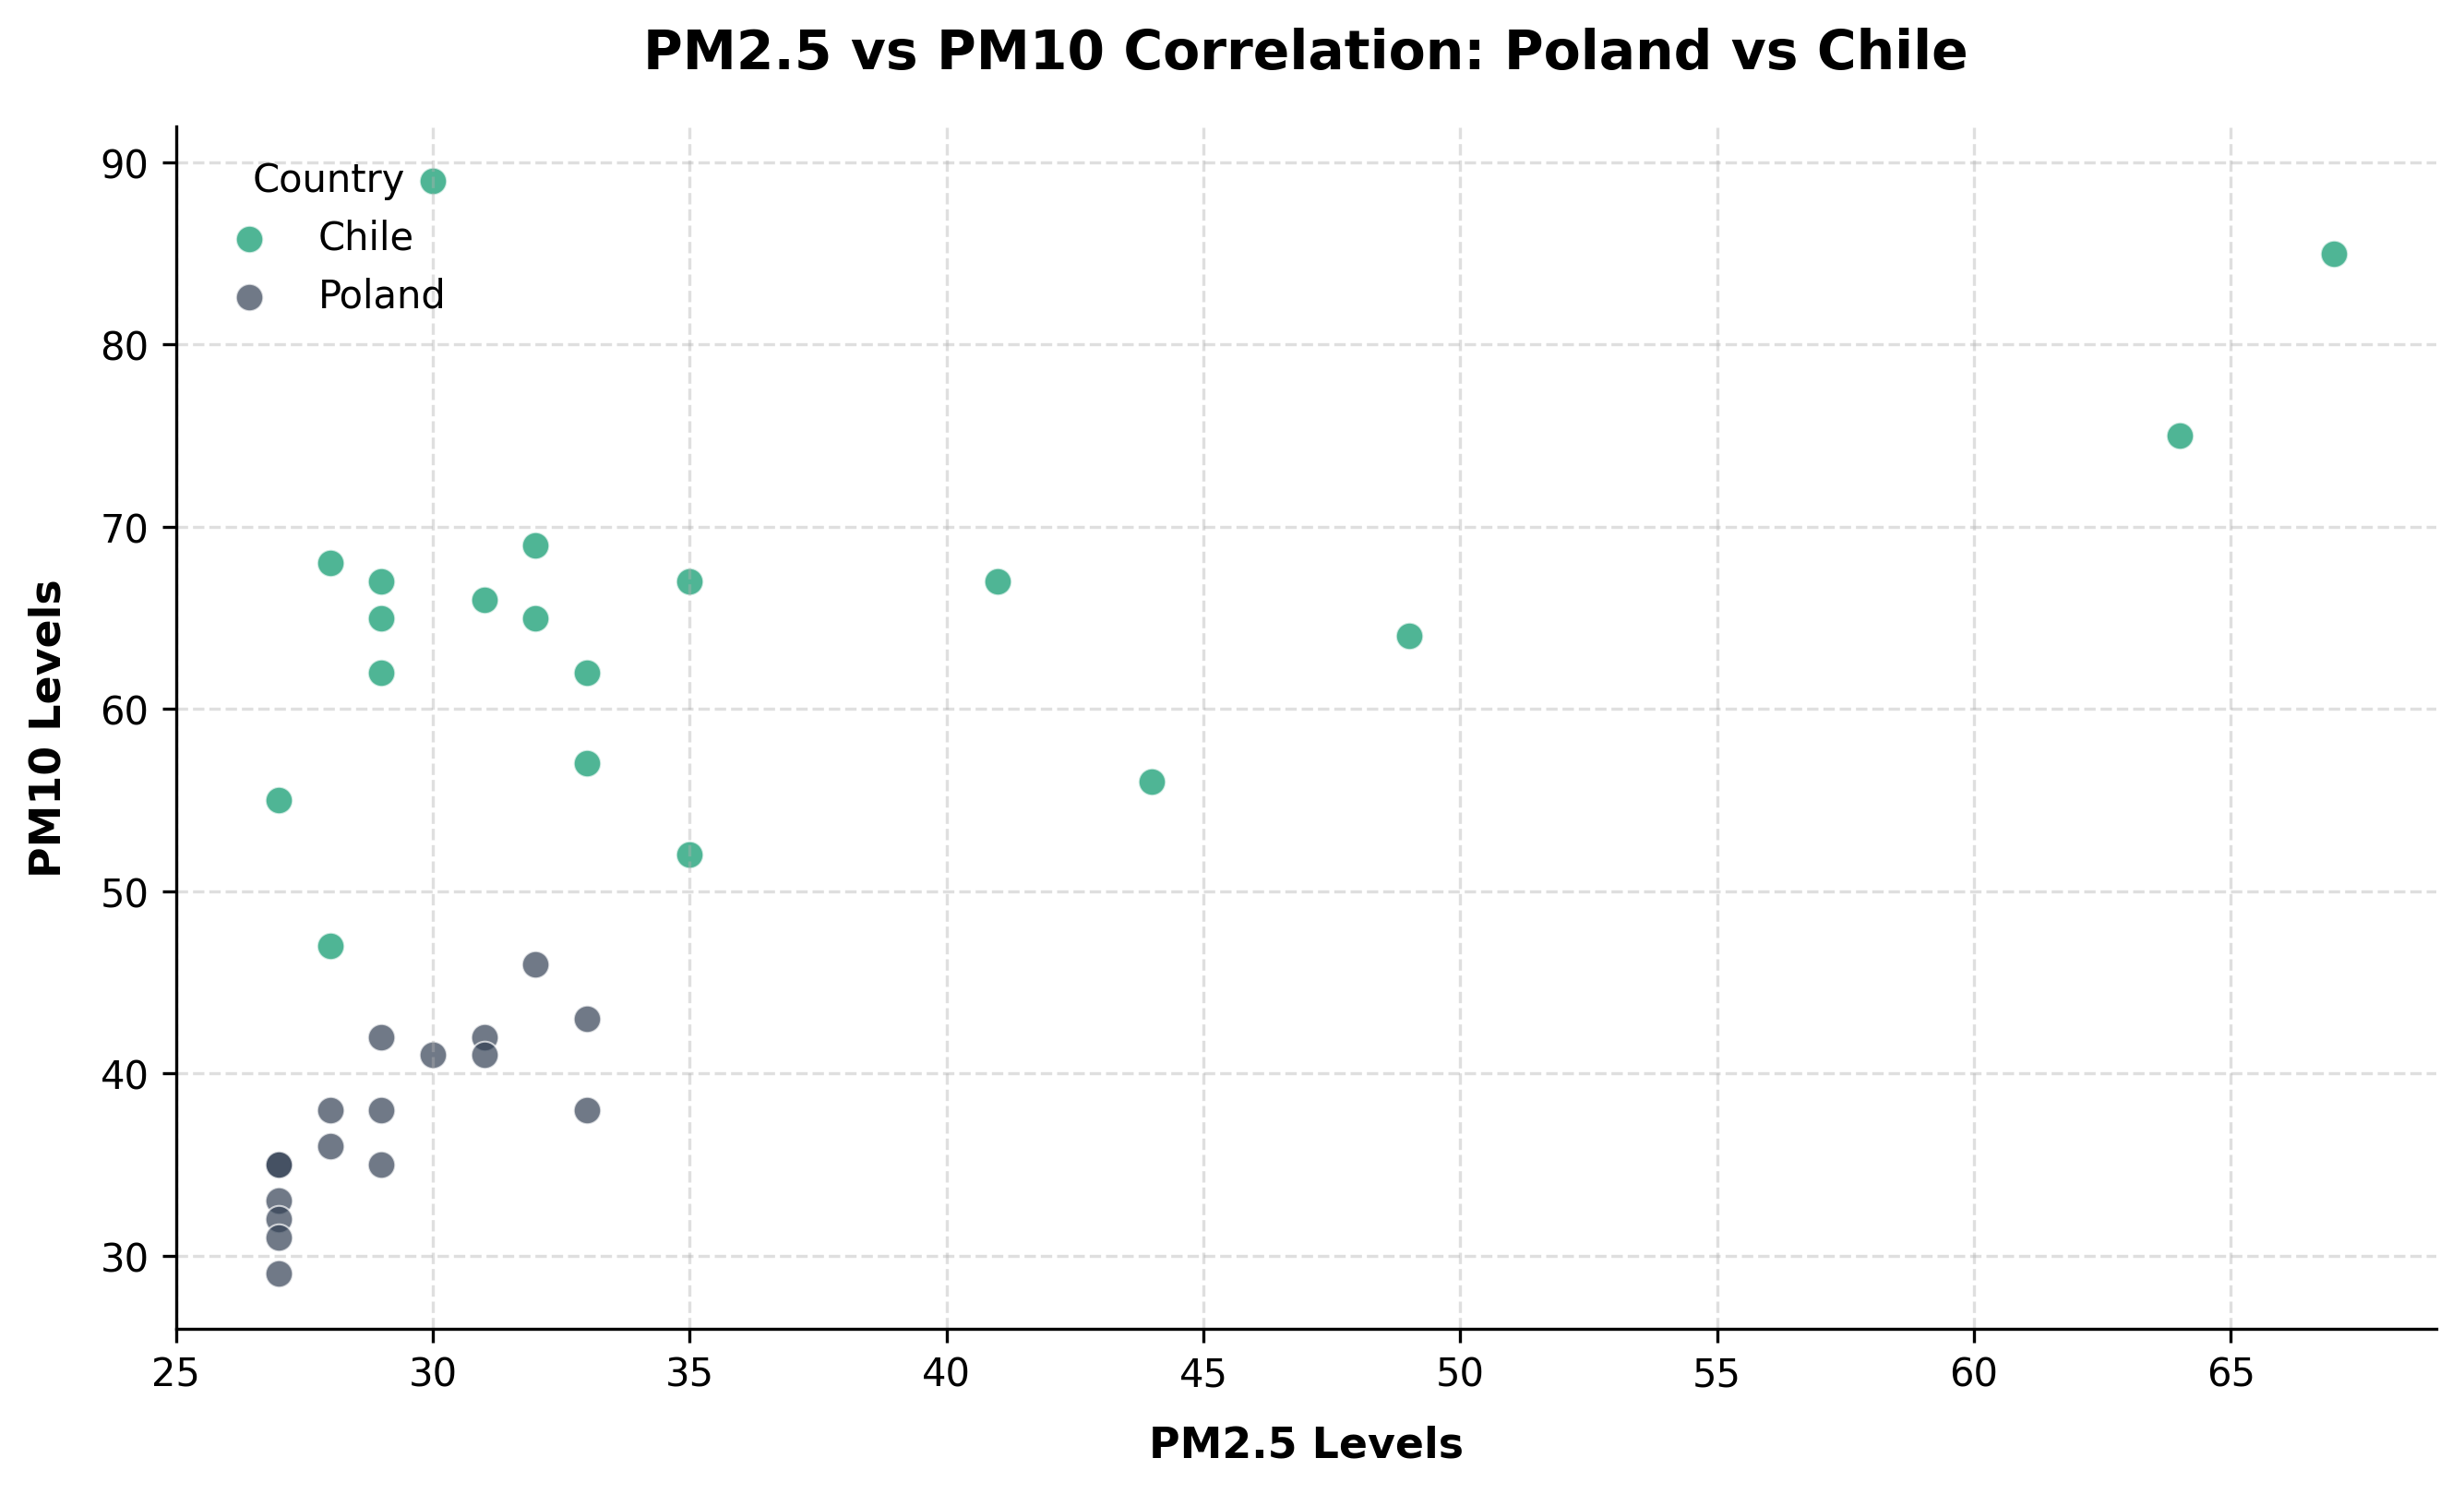

In [76]:
# Select only the rows where the country is either Poland or Chile.
#
# dropna() removes rows where either PM2.5 or PM10 is missing.
# We remove these rows because a scatter plot needs both values
# to plot a complete point.
poland_chile = (
    df[
        df["Country"].isin(["Poland", "Chile"])
    ]
    .dropna(subset=["PM2.5", "PM10"])
)


# Create the figure with a fixed size and high resolution.
#
# figsize controls the width and height of the chart.
# dpi=300 creates a sharp, high-resolution figure.
plt.figure(
    figsize=(9, 5.5),
    dpi=300
)


# Create a separate color for each country.
# The dictionary allows us to easily choose the correct color
# while creating the scatter plot.
colors = {
    "Poland": "#334155",
    "Chile": "#059669"
}


# Create a separate scatter plot for each country.
#
# groupby("Country") separates the filtered data into two groups:
#
# 1. All rows belonging to Poland
# 2. All rows belonging to Chile
#
# In each loop:
# - country contains the country name
# - group contains only the rows for that country
for country, group in poland_chile.groupby("Country"):

    # Create a scatter plot using PM2.5 on the x-axis
    # and PM10 on the y-axis.
    #
    # Each dot represents one observation from the dataset.
    plt.scatter(
        group["PM2.5"],
        group["PM10"],

        # Add the country name to the legend.
        label=country,

        # Select the color based on the current country.
        color=colors[country],

        # Make the points slightly transparent.
        # This makes overlapping points easier to see.
        alpha=0.7,

        # Add a white border around each point
        # to make individual points easier to distinguish.
        edgecolor="white",

        # Set the thickness of the marker border.
        linewidth=0.5,

        # Control the size of each marker.
        s=50
    )


# Display normal numbers on both axes instead of scientific notation.
# This makes large PM2.5 and PM10 values easier to read.
plt.ticklabel_format(
    style="plain",
    axis="both"
)


# Add a label to the x-axis.
# The x-axis represents PM2.5 values.
plt.xlabel(
    "PM2.5 Levels",
    fontsize=11,
    fontweight="bold",
    labelpad=8
)


# Add a label to the y-axis.
# The y-axis represents PM10 values.
plt.ylabel(
    "PM10 Levels",
    fontsize=11,
    fontweight="bold",
    labelpad=8
)


# Add a title that explains the purpose of the chart.
# The scatter plot helps us visually examine the relationship
# between PM2.5 and PM10 for Poland and Chile.
plt.title(
    "PM2.5 vs PM10 Correlation: Poland vs Chile",
    fontsize=14,
    fontweight="bold",
    pad=15
)


# Add grid lines to make the values easier to compare.
# Dashed lines keep the chart visually simple.
plt.grid(
    True,
    linestyle="--",
    alpha=0.4
)


# Remove the top and right borders of the chart.
# This creates a cleaner and less crowded appearance.
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)


# Add a legend to identify the points belonging to each country.
# The legend title explains what the colors represent.
plt.legend(
    title="Country",
    frameon=False,
    loc="upper left"
)


# Automatically adjust the spacing around the chart
# so that labels and the title are not cut off.
plt.tight_layout()


# Save the final scatter plot as a high-resolution PNG image.
#
# dpi=300 keeps the saved image sharp.
# bbox_inches="tight" removes unnecessary extra space around the chart.
plt.savefig(
    "plots/problem3_poland_chile_scatter.png",
    dpi=300,
    bbox_inches="tight"
)


# Display the chart in the notebook.
plt.show()

### **`Problem-4:`** Draw a pie chart of top 5 most frequent countries.

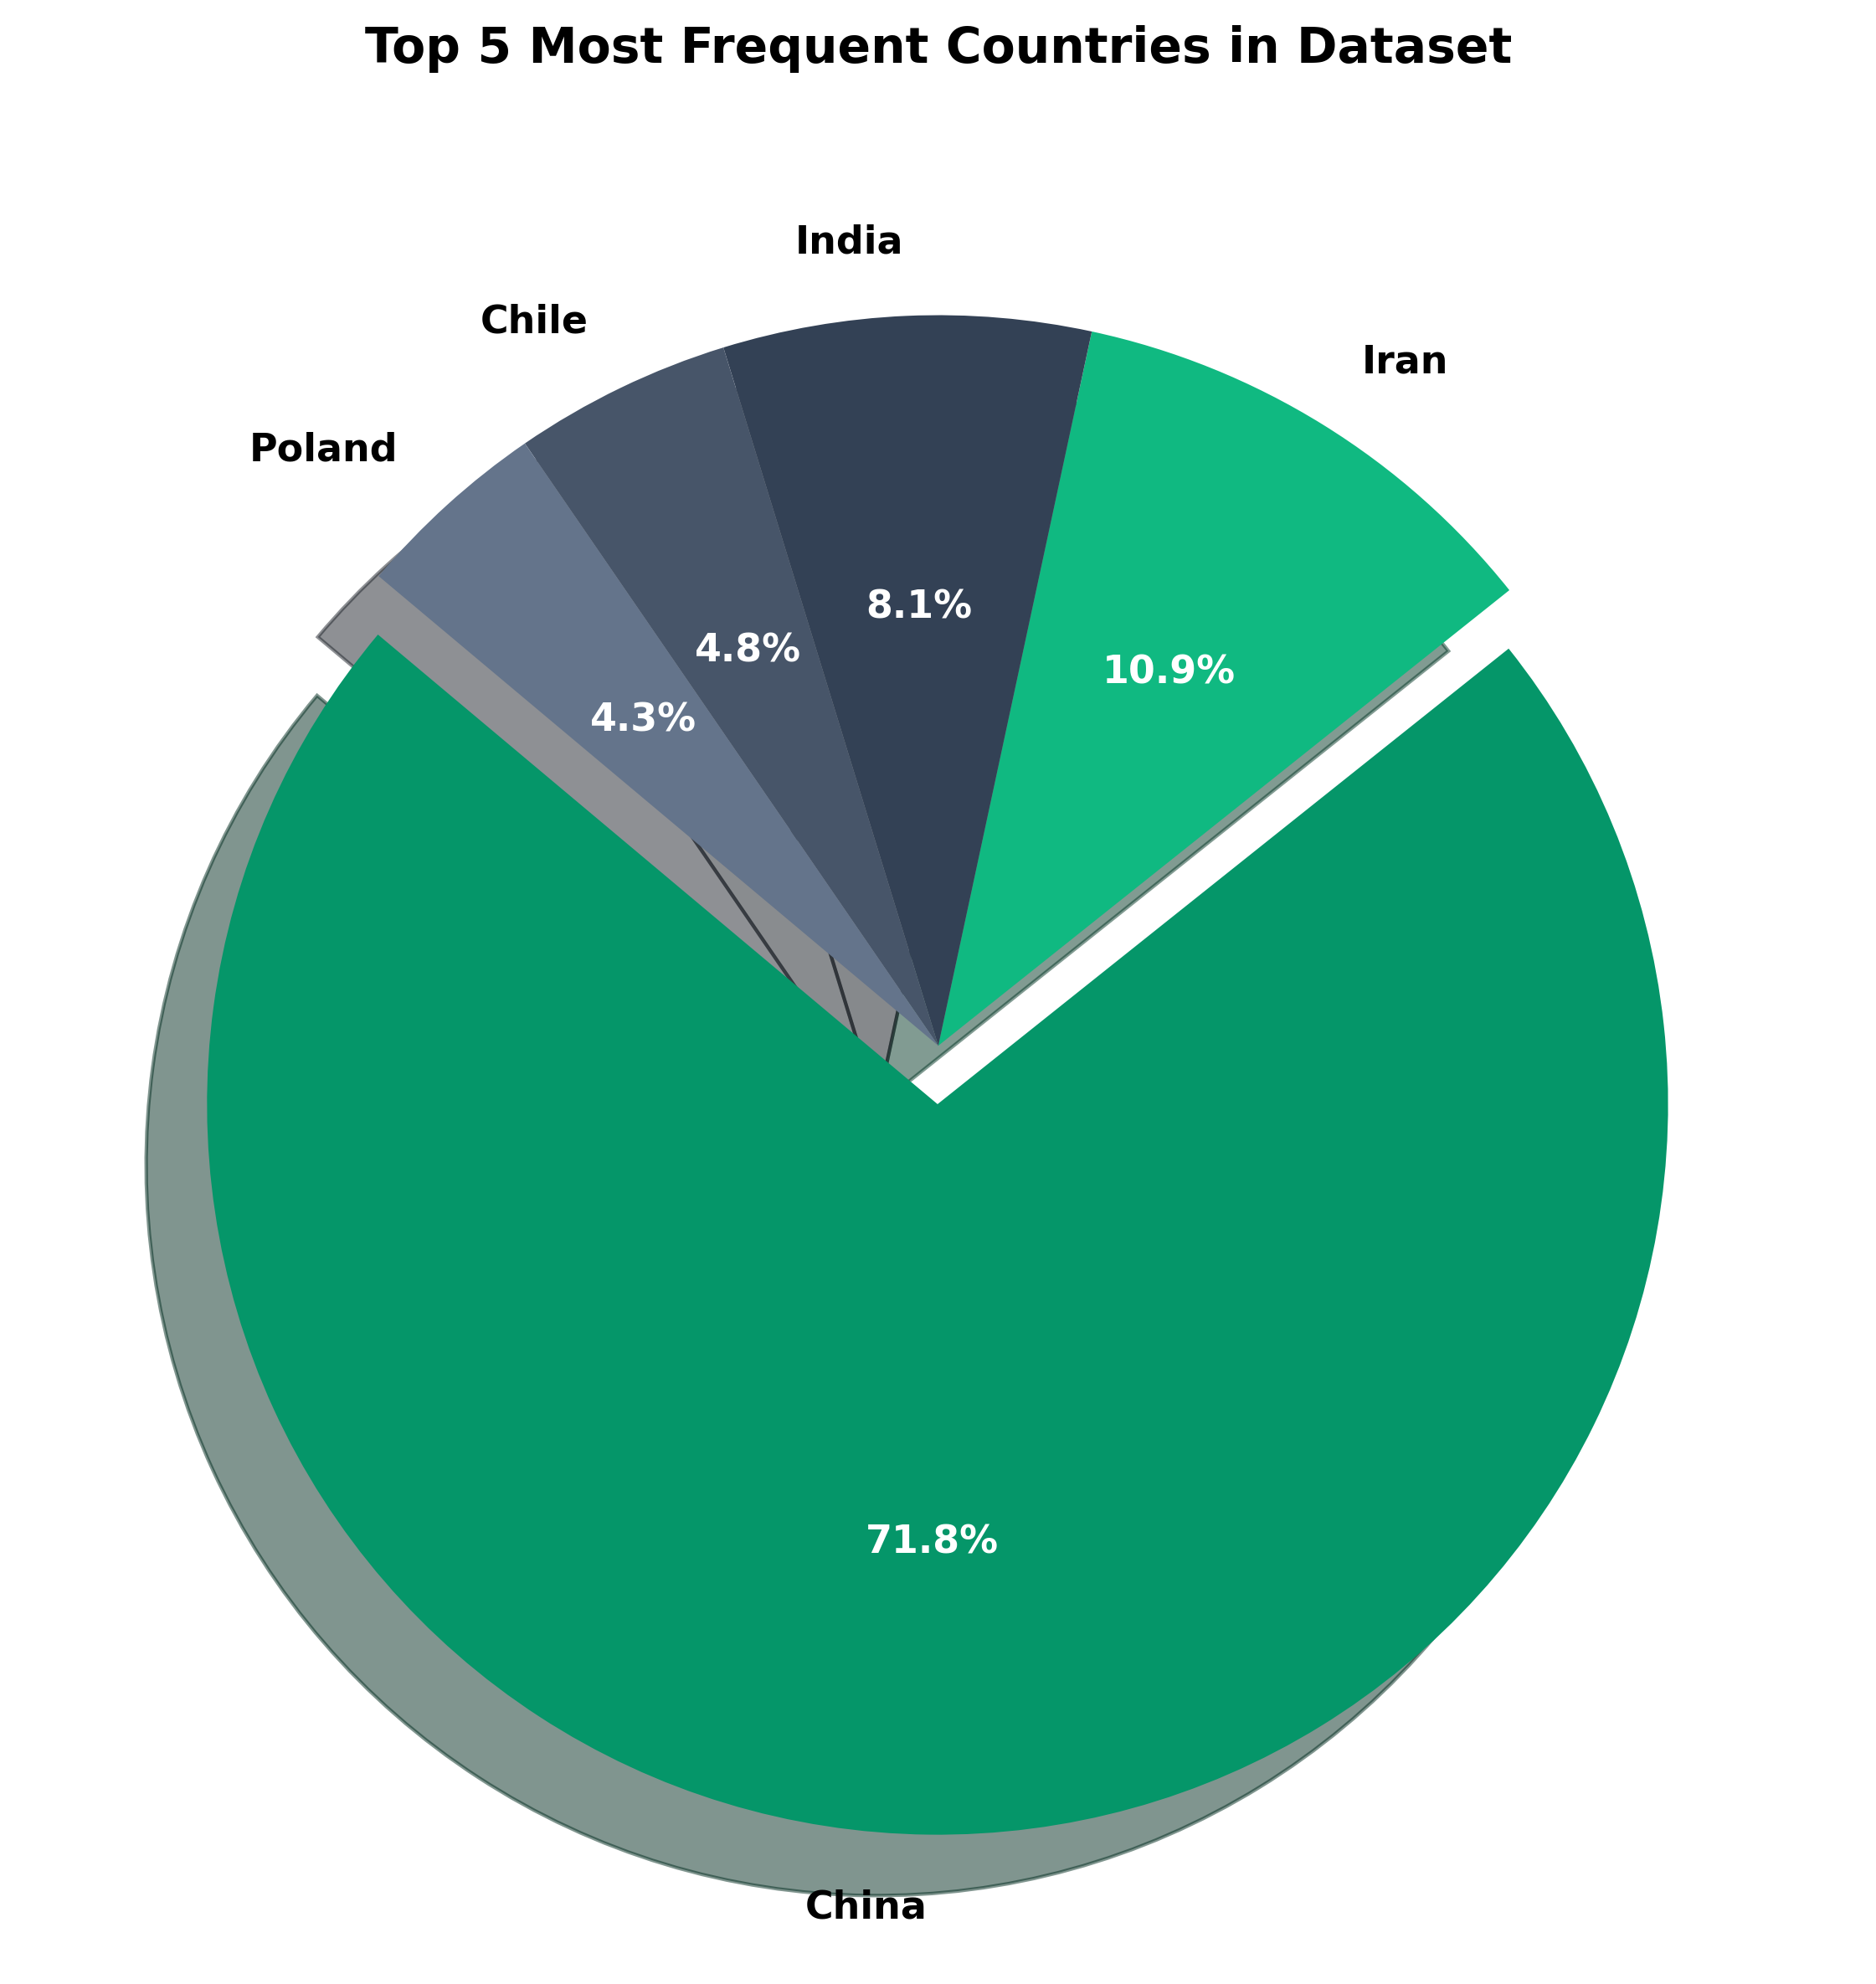

In [77]:
# Count how many times each country appears in the dataset.
# Then select only the five countries with the highest number of records.
#
# value_counts() counts the frequency of each unique country.
# head(5) keeps only the first five countries after sorting
# them from most frequent to least frequent.
top_5_countries = (
    df["Country"]
    .value_counts()
    .head(5)
)


# Define a separate color for each country slice.
# The colors are assigned in the same order as the values
# in top_5_countries.
colors = [
    "#059669",
    "#10B981",
    "#334155",
    "#475569",
    "#64748B"
]


# Move the first slice slightly away from the center.
#
# The first value belongs to the country with the highest number
# of records, so this helps highlight the most frequent country.
#
# 0.08 means the first slice is moved slightly outward.
# The remaining values are kept at 0, so those slices stay in place.
explode = (
    0.08,
    0,
    0,
    0,
    0
)


# Create a square figure for the pie chart.
# A square figure works well because a pie chart is circular.
# dpi=300 creates a high-resolution figure.
plt.figure(
    figsize=(8, 8),
    dpi=300
)


# Create the pie chart using the top five countries.
#
# values are used to calculate the size of each slice.
# labels display the country names.
# autopct displays the percentage of each country.
# startangle rotates the chart to improve the starting position.
# colors applies the colors defined above.
# explode separates the first slice slightly from the rest.
# shadow adds a subtle depth effect.
#
# The returned objects are:
# - wedges: the individual slices of the pie chart
# - texts: the country labels
# - autotexts: the percentage labels
wedges, texts, autotexts = plt.pie(
    top_5_countries.values,
    labels=top_5_countries.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=colors,
    explode=explode,
    shadow=True,
    textprops={
        "fontsize": 11,
        "fontweight": "bold"
    }
)


# Change the color of the percentage labels to white.
# White text provides better contrast against the darker slices.
for autotext in autotexts:
    autotext.set_color("white")


# Add a clear title to explain what the pie chart represents.
plt.title(
    "Top 5 Most Frequent Countries in Dataset",
    fontsize=14,
    fontweight="bold",
    pad=20
)


# Automatically adjust the spacing around the chart
# so that the title and labels are not cut off.
plt.tight_layout()


# Save the pie chart as a high-resolution PNG image.
#
# dpi=300 keeps the saved image sharp.
# bbox_inches="tight" removes unnecessary empty space
# around the chart.
plt.savefig(
    "plots/problem4_top5_countries_pie.png",
    dpi=300,
    bbox_inches="tight"
)


# Display the final pie chart in the notebook.
plt.show()

### **`Problem-5:`** Draw a bar chart which represents the counts of top 5 most frequent countries.



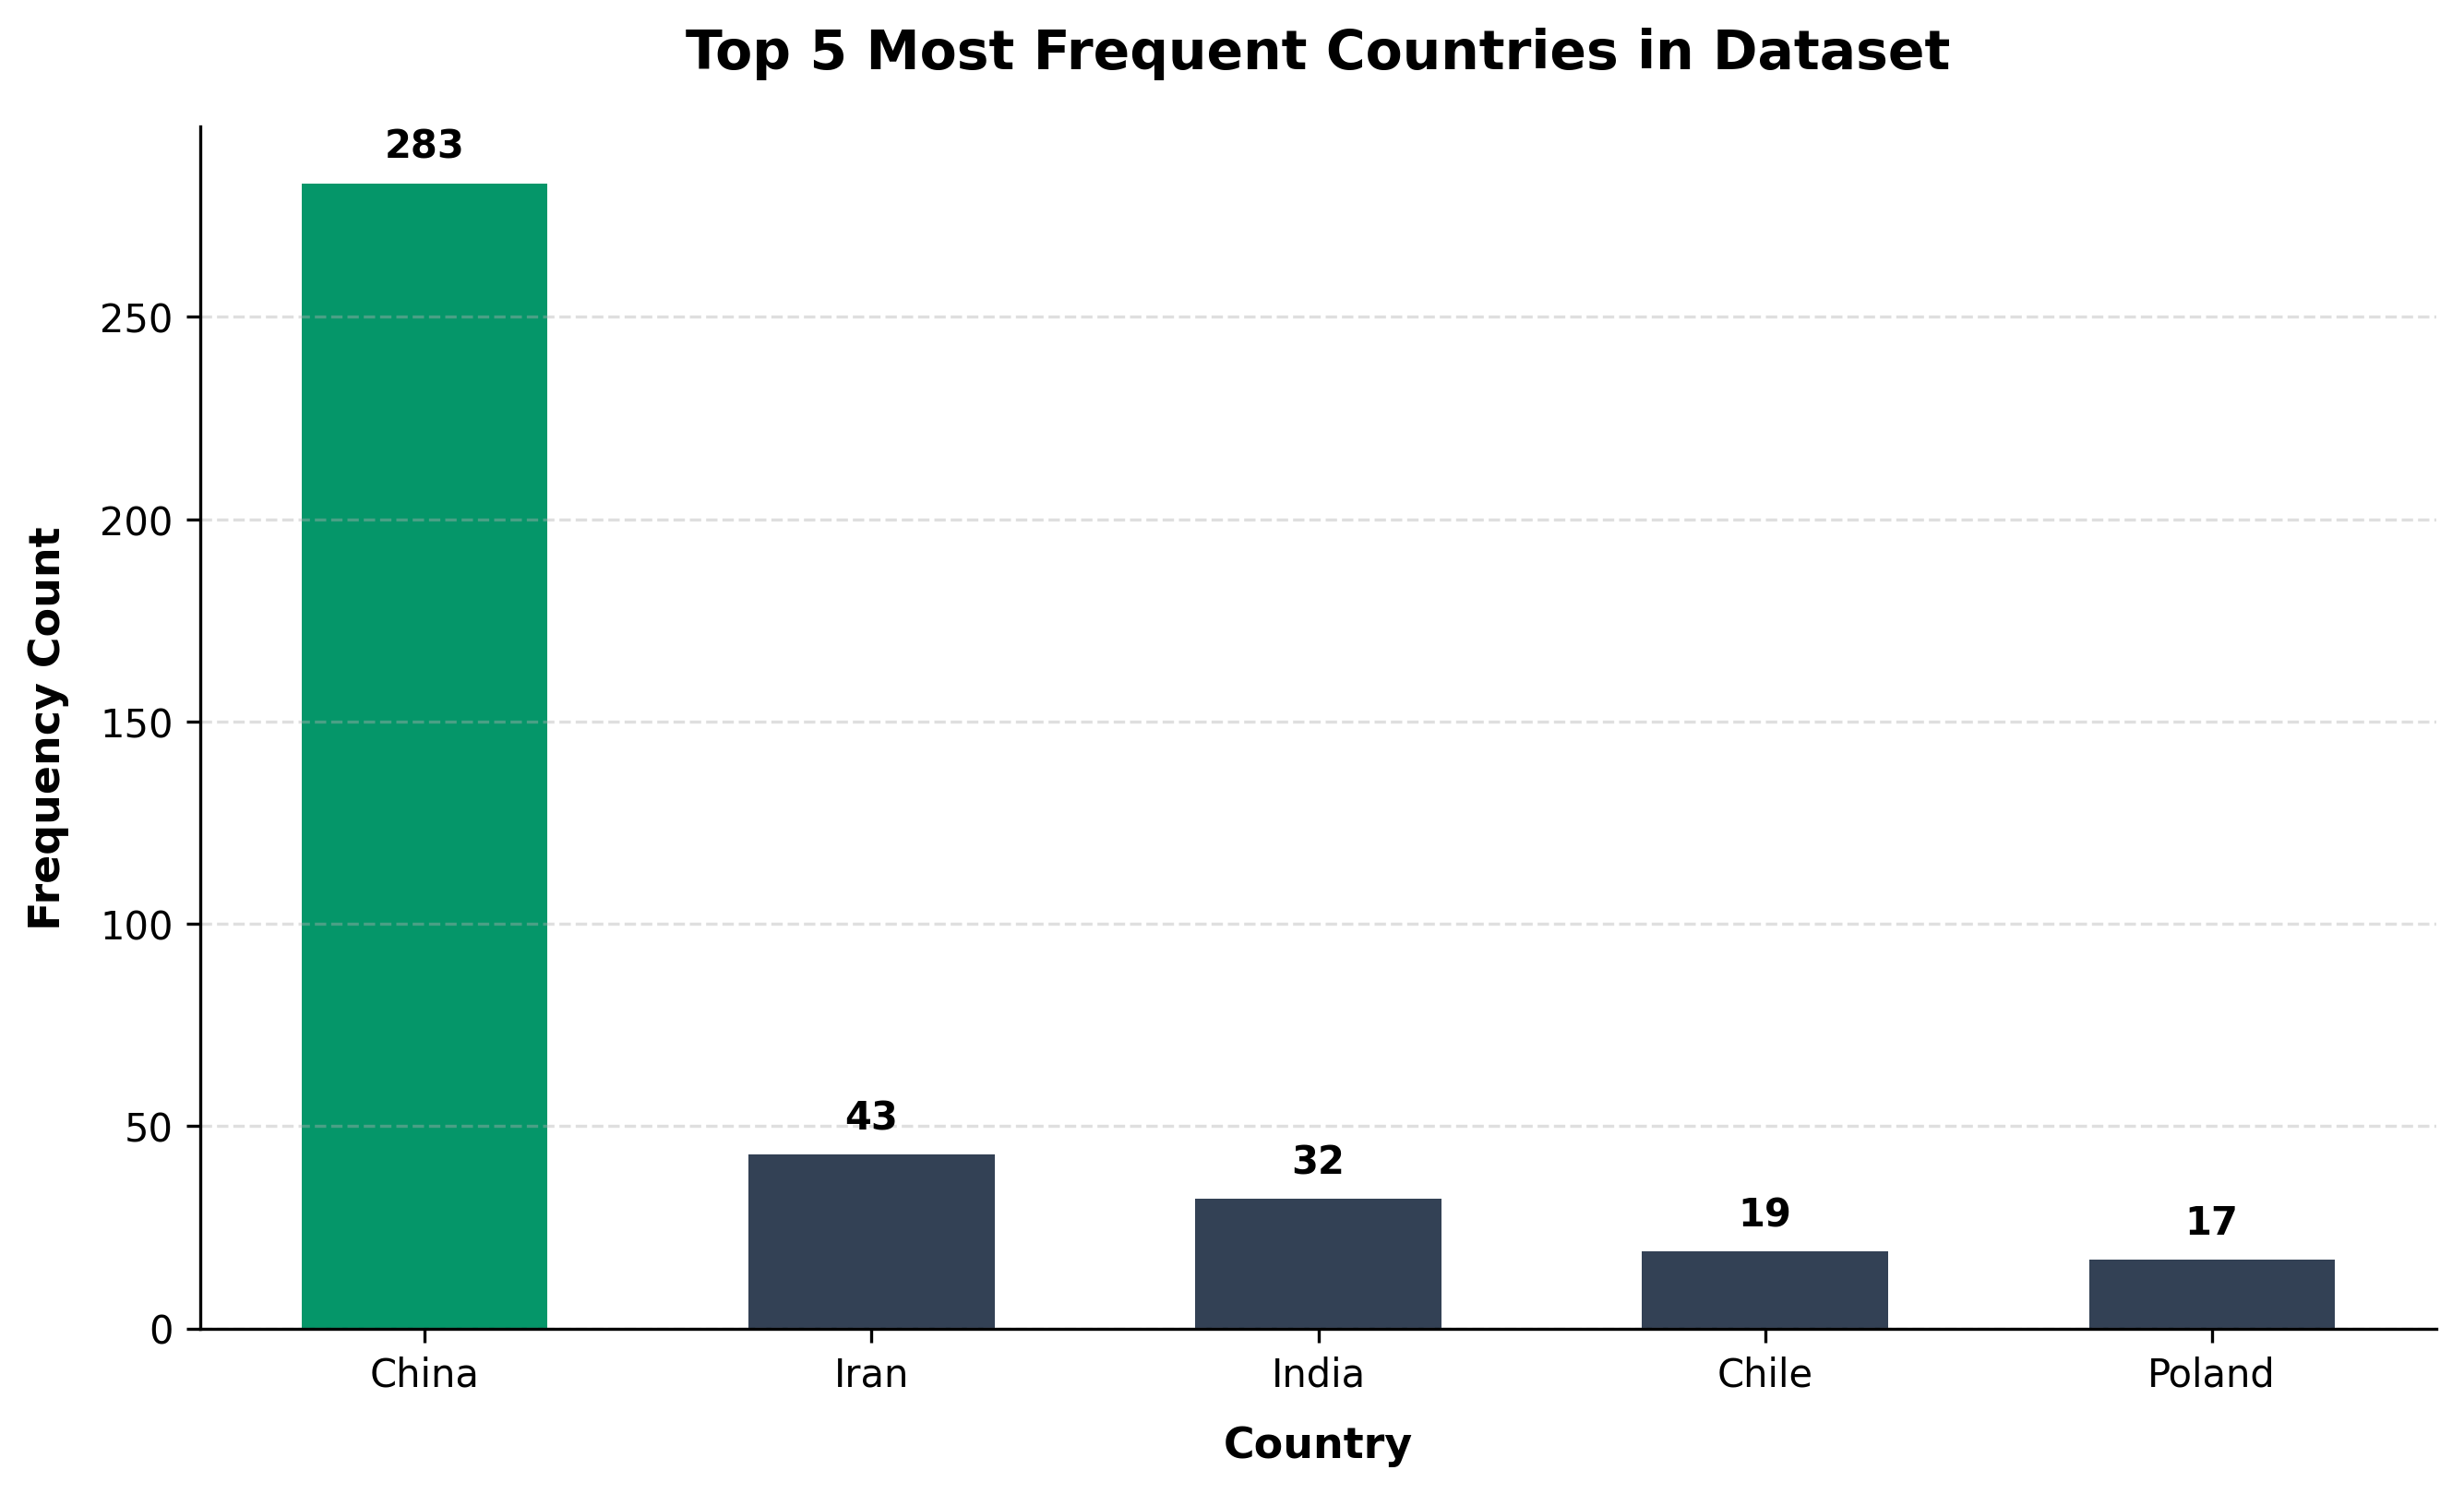

In [ ]:
# Count how many records belong to each country.
# Then keep only the five countries with the highest number of records.
#
# value_counts() counts the frequency of each unique country.
# head(5) selects the first five countries after sorting
# them from most frequent to least frequent.
top_5_countries = (
    df["Country"]
    .value_counts()
    .head(5)
)


# Create the figure with a fixed size and high resolution.
# dpi=300 creates a sharp image when the chart is saved.
plt.figure(
    figsize=(9, 5.5),
    dpi=300
)


# Highlight the country with the highest frequency using a different color.
# The remaining four countries use the same color.
colors = [
    "#059669"
] + [
    "#334155"
] * 4


# Create the bar chart.
#
# top_5_countries.index contains the country names.
# top_5_countries.values contains the number of records for each country.
#
# width controls the width of each bar.
# edgecolor="none" removes the border around the bars.
bars = plt.bar(
    top_5_countries.index,
    top_5_countries.values,
    color=colors,
    width=0.55,
    edgecolor="none"
)


# Add the exact frequency value above each bar.
#
# The loop goes through each bar one by one.
for bar in bars:

    # Get the height of the current bar.
    # The height represents the number of records for that country.
    yval = bar.get_height()


    # Place the exact count above the current bar.
    #
    # bar.get_x() gives the left position of the bar.
    # bar.get_width() gives the width of the bar.
    #
    # Adding half of the width gives the center of the bar.
    # This keeps the text horizontally centered.
    #
    # yval + a small extra space places the text slightly above the bar.
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        yval + (max(top_5_countries.values) * 0.015),
        f"{int(yval):,}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )


# Display normal numbers on the y-axis instead of scientific notation.
# This makes large frequency values easier to read.
plt.ticklabel_format(
    style="plain",
    axis="y"
)


# Remove the top and right borders of the chart.
# This gives the chart a cleaner and less crowded appearance.
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)


# Add a label to the x-axis.
# The x-axis represents the countries.
plt.xlabel(
    "Country",
    fontsize=11,
    fontweight="bold",
    labelpad=8
)


# Add a label to the y-axis.
# The y-axis shows how many records belong to each country.
plt.ylabel(
    "Frequency Count",
    fontsize=11,
    fontweight="bold",
    labelpad=8
)


# Add a clear title that explains what the chart shows.
plt.title(
    "Top 5 Most Frequent Countries in Dataset",
    fontsize=14,
    fontweight="bold",
    pad=15
)


# Add horizontal grid lines to make it easier to compare
# the heights of the bars.
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)


# Automatically adjust the spacing around the chart
# so that labels and the title are not cut off.
plt.tight_layout()


# Save the chart as a high-resolution PNG image.
#
# dpi=300 keeps the image sharp.
# bbox_inches="tight" removes unnecessary empty space
# around the chart.
plt.savefig(
    "plots/problem5_top5_countries_bar.png",
    dpi=300,
    bbox_inches="tight"
)


# Display the final bar chart in the notebook.
plt.show()

## `Problem 6-10`
Data Set - https://docs.google.com/spreadsheets/d/e/2PACX-1vTJh6X4_mqixWsfK9mgkllGQkKYW9Wj9kOIMGY2uYsWeS8n5np87DO-SDGQWJ1HXEnxiOVFVzYFYEcR/pub?gid=558678488&single=true&output=csv

This is a Sales data of any company in a Year.


### `Problem-6`
Show a line plot of Total Profit for each month with below styling.
* Dotted Line
* Line Color Blue
* Show Legend at top left
* Circle Marker

In [82]:
# code here
df = pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vTJh6X4_mqixWsfK9mgkllGQkKYW9Wj9kOIMGY2uYsWeS8n5np87DO-SDGQWJ1HXEnxiOVFVzYFYEcR/pub?gid=558678488&single=true&output=csv')
df

,month_number,facecream,facewash,toothpaste,bathingsoap,shampoo,moisturizer,total_units,total_profit
0,1,2500,1500,5200,9200,1200,1500,21100,211000
1,2,2630,1200,5100,6100,2100,1200,18330,183300
2,3,2140,1340,4550,9550,3550,1340,22470,224700
3,4,3400,1130,5870,8870,1870,1130,22270,222700
4,5,3600,1740,4560,7760,1560,1740,20960,209600
5,6,2760,1555,4890,7490,1890,1555,20140,201400
6,7,2980,1120,4780,8980,1780,1120,29550,295500
7,8,3700,1400,5860,9960,2860,1400,36140,361400
8,9,3540,1780,6100,8100,2100,1780,23400,234000
9,10,1990,1890,8300,10300,2300,1890,26670,266700


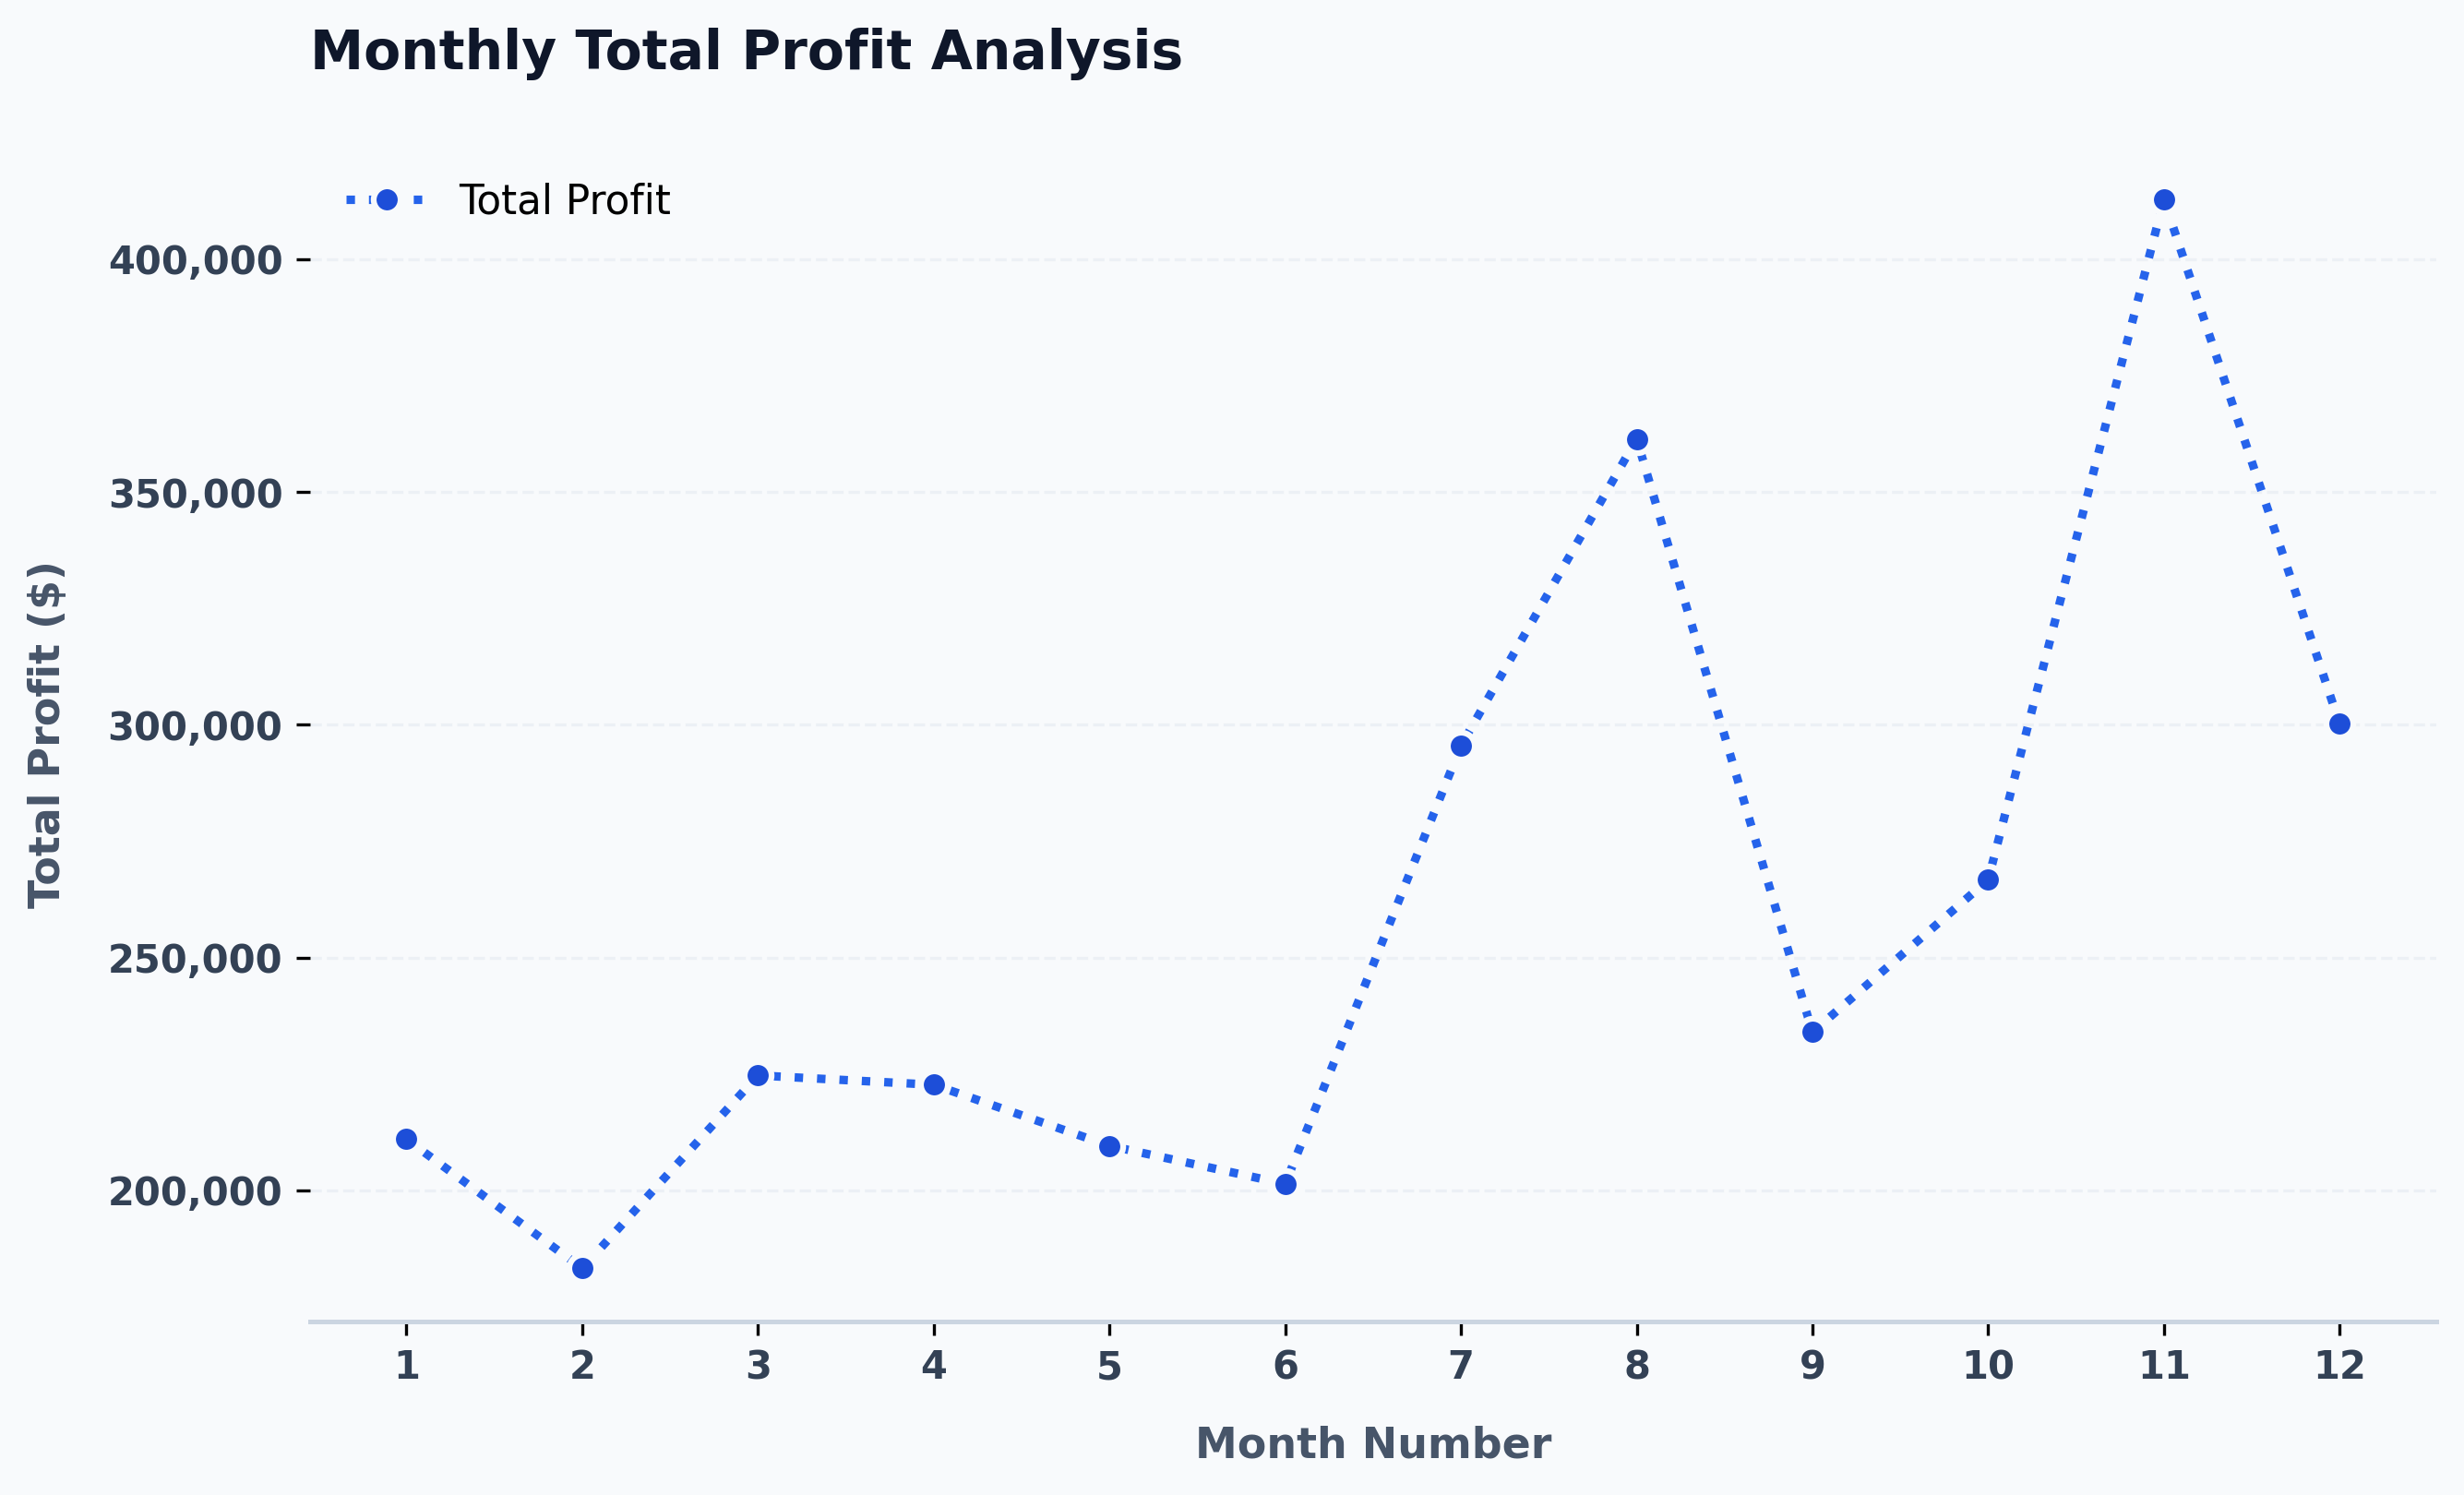

In [84]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


# Create the figure and the axes for the chart.
#
# figsize controls the width and height of the figure.
# dpi=300 creates a high-resolution chart.
#
# fig represents the complete figure.
# ax represents the actual area where the chart is drawn.
fig, ax = plt.subplots(
    figsize=(9, 5.5),
    dpi=300
)


# Set a light background color for the complete figure.
# This gives the chart a clean and professional appearance.
fig.patch.set_facecolor("#F8FAFC")


# Set the same background color for the plotting area.
ax.set_facecolor("#F8FAFC")


# Plot the monthly total profit values.
#
# month_number is used on the x-axis.
# total_profit is used on the y-axis.
#
# label is used to identify the line in the legend.
# linestyle=":" creates a dotted line.
# marker="o" adds a circle at each month's data point.
# linewidth controls the thickness of the line.
# markersize controls the size of the circles.
#
# markerfacecolor sets the color inside each marker.
# markeredgecolor sets the color of the marker's border.
# markeredgewidth controls the thickness of the marker border.
ax.plot(
    df["month_number"],
    df["total_profit"],
    label="Total Profit",
    color="#2563EB",
    linestyle=":",
    marker="o",
    linewidth=2.2,
    markersize=7,
    markerfacecolor="#1D4ED8",
    markeredgecolor="#F8FAFC",
    markeredgewidth=1.5
)


# Format the y-axis values with commas and without decimal places.
#
# For example:
#
# 1000000.0  →  1,000,000
#
# The format string "{x:,.0f}" means:
# - "," adds comma separators
# - ".0f" shows zero decimal places
ax.yaxis.set_major_formatter(
    ticker.StrMethodFormatter("{x:,.0f}")
)


# Remove unnecessary borders from the top, right, and left sides
# of the chart to create a cleaner appearance.
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)


# Keep the bottom border visible as the main x-axis line.
ax.spines["bottom"].set_color("#CBD5E1")


# Make the bottom axis line slightly thicker.
ax.spines["bottom"].set_linewidth(1.2)


# Display all month numbers from 1 to 12 on the x-axis.
#
# df["month_number"] provides the exact positions of the months.
# The remaining arguments control the appearance of the labels.
plt.xticks(
    df["month_number"],
    fontsize=10,
    fontweight="bold",
    color="#334155"
)


# Customize the appearance of the y-axis labels.
plt.yticks(
    fontsize=10,
    fontweight="bold",
    color="#334155"
)


# Add a clear title that explains what the chart shows.
plt.title(
    "Monthly Total Profit Analysis",
    fontsize=14,
    fontweight="bold",
    color="#0F172A",
    pad=20,
    loc="left"
)


# Add a label to the x-axis.
# The x-axis represents the month numbers.
plt.xlabel(
    "Month Number",
    fontsize=11,
    fontweight="bold",
    color="#475569",
    labelpad=10
)


# Add a label to the y-axis.
# The y-axis represents the total profit for each month.
plt.ylabel(
    "Total Profit ($)",
    fontsize=11,
    fontweight="bold",
    color="#475569",
    labelpad=10
)


# Add horizontal grid lines to make it easier to compare
# profit values across different months.
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5,
    color="#E2E8F0"
)


# Add a legend to identify the plotted line.
# frameon=False removes the box around the legend.
plt.legend(
    loc="upper left",
    frameon=False,
    fontsize=10.5
)


# Automatically adjust the spacing around the chart
# so that labels and the title do not overlap or get cut off.
plt.tight_layout()


# Save the final chart as a high-resolution PNG image.
#
# dpi=300 keeps the saved image sharp.
# facecolor keeps the same background color in the saved image.
# edgecolor="none" removes any extra border around the saved figure.
# bbox_inches="tight" removes unnecessary empty space around the chart.
plt.savefig(
    "plots/problem6_total_profit_line.png",
    dpi=300,
    facecolor=fig.get_facecolor(),
    edgecolor="none",
    bbox_inches="tight"
)


# Display the chart in the notebook.
plt.show()

### `Problem-7`
Show sales of each product in march month as pie chart.
* Show Percentage value
* Give Title "Sales in March"
* Explode ToothPaste with shadow

In [51]:
df

,month_number,facecream,facewash,toothpaste,bathingsoap,shampoo,moisturizer,total_units,total_profit
0,1,2500,1500,5200,9200,1200,1500,21100,211000
1,2,2630,1200,5100,6100,2100,1200,18330,183300
2,3,2140,1340,4550,9550,3550,1340,22470,224700
3,4,3400,1130,5870,8870,1870,1130,22270,222700
4,5,3600,1740,4560,7760,1560,1740,20960,209600
5,6,2760,1555,4890,7490,1890,1555,20140,201400
6,7,2980,1120,4780,8980,1780,1120,29550,295500
7,8,3700,1400,5860,9960,2860,1400,36140,361400
8,9,3540,1780,6100,8100,2100,1780,23400,234000
9,10,1990,1890,8300,10300,2300,1890,26670,266700


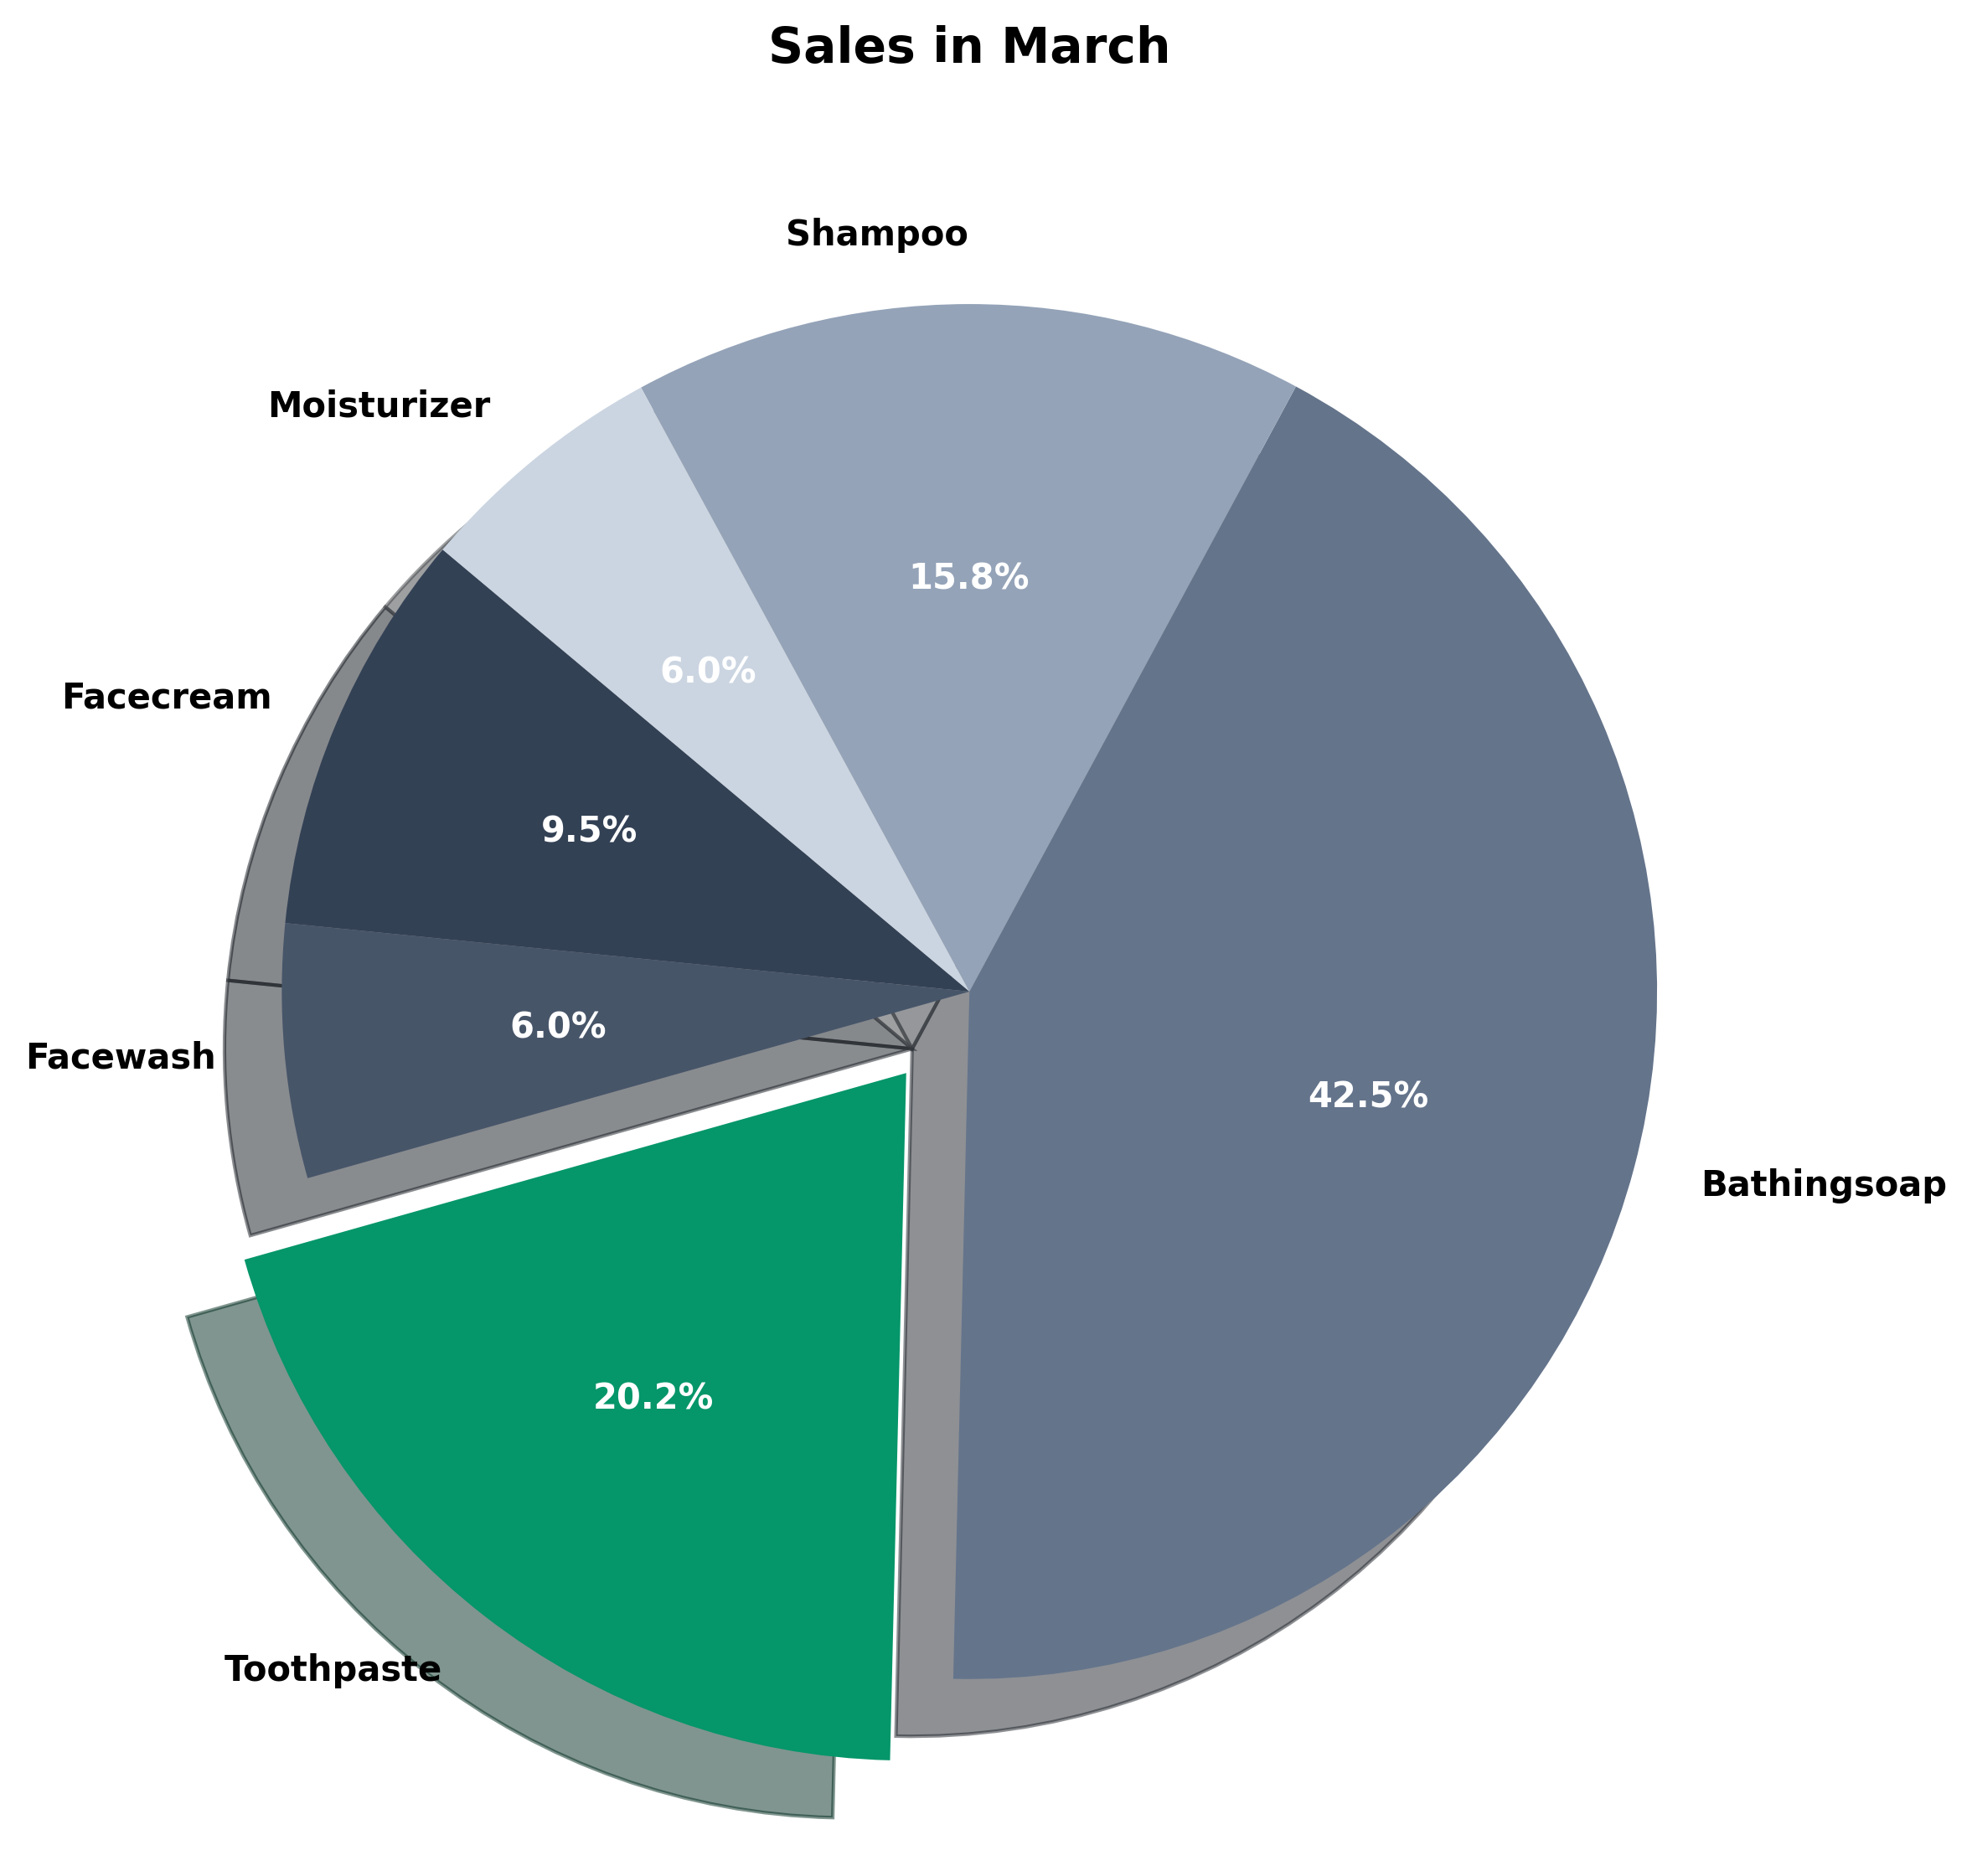

In [85]:
# Select only the row where the month number is 3.
# Month number 3 represents March.
march_data = df[
    df["month_number"] == 3
]


# Store the names of all products that we want to compare.
products = [
    "facecream",
    "facewash",
    "toothpaste",
    "bathingsoap",
    "shampoo",
    "moisturizer"
]


# Get the sales value of each product for March.
#
# march_data[product] selects one product column.
# .values returns the values from that column as an array.
# [0] gets the first value from the array.
#
# A list comprehension repeats this process for every product
# in the products list.
sales_values = [
    march_data[product].values[0]
    for product in products
]


# Move the toothpaste slice slightly away from the center
# to highlight its share of the total March sales.
#
# The position of each value matches the position of each product:
#
# 0 → Facecream
# 1 → Facewash
# 2 → Toothpaste
# 3 → Bathing Soap
# 4 → Shampoo
# 5 → Moisturizer
#
# Only the value at index 2 is greater than zero,
# so only the toothpaste slice will move outward.
explode = [
    0,
    0,
    0.15,
    0,
    0,
    0
]


# Define a separate color for each product slice.
# The colors are assigned in the same order as the products list.
colors = [
    "#334155",
    "#475569",
    "#059669",
    "#64748B",
    "#94A3B8",
    "#CBD5E1"
]


# Create a square figure for the pie chart.
# A square figure works well for a circular chart.
# dpi=300 creates a high-resolution figure.
plt.figure(
    figsize=(8, 8),
    dpi=300
)


# Create the pie chart using the March sales values.
#
# sales_values determines the size of each slice.
# labels displays the product names.
# autopct displays the percentage of total March sales.
# startangle rotates the chart to improve the starting position.
# colors applies the product colors defined above.
# explode separates the toothpaste slice from the center.
# shadow adds a subtle depth effect.
#
# The pie() function returns three groups of objects:
# - wedges: the individual pie slices
# - texts: the product name labels
# - autotexts: the percentage labels
wedges, texts, autotexts = plt.pie(
    sales_values,
    labels=[
        product.capitalize()
        for product in products
    ],
    autopct="%1.1f%%",
    startangle=140,
    colors=colors,
    explode=explode,
    shadow=True,
    textprops={
        "fontsize": 10,
        "fontweight": "bold"
    }
)


# Change the percentage text color to white.
# This improves the contrast between the percentage labels
# and the colored pie slices.
for autotext in autotexts:
    autotext.set_color("white")


# Add a clear title to explain what the chart represents.
plt.title(
    "Sales in March",
    fontsize=14,
    fontweight="bold",
    pad=20
)


# Automatically adjust the spacing around the chart
# so that labels and the title are not cut off.
plt.tight_layout()


# Save the final pie chart as a high-resolution PNG image.
#
# dpi=300 keeps the saved image sharp.
# bbox_inches="tight" removes unnecessary empty space
# around the chart.
plt.savefig(
    "plots/problem7_march_sales_pie.png",
    dpi=300,
    bbox_inches="tight"
)


# Display the chart in the notebook.
plt.show()

### `Problem-8` Multiline Plot of all products sales.
* Give different styes for each products
* Add legend at top right

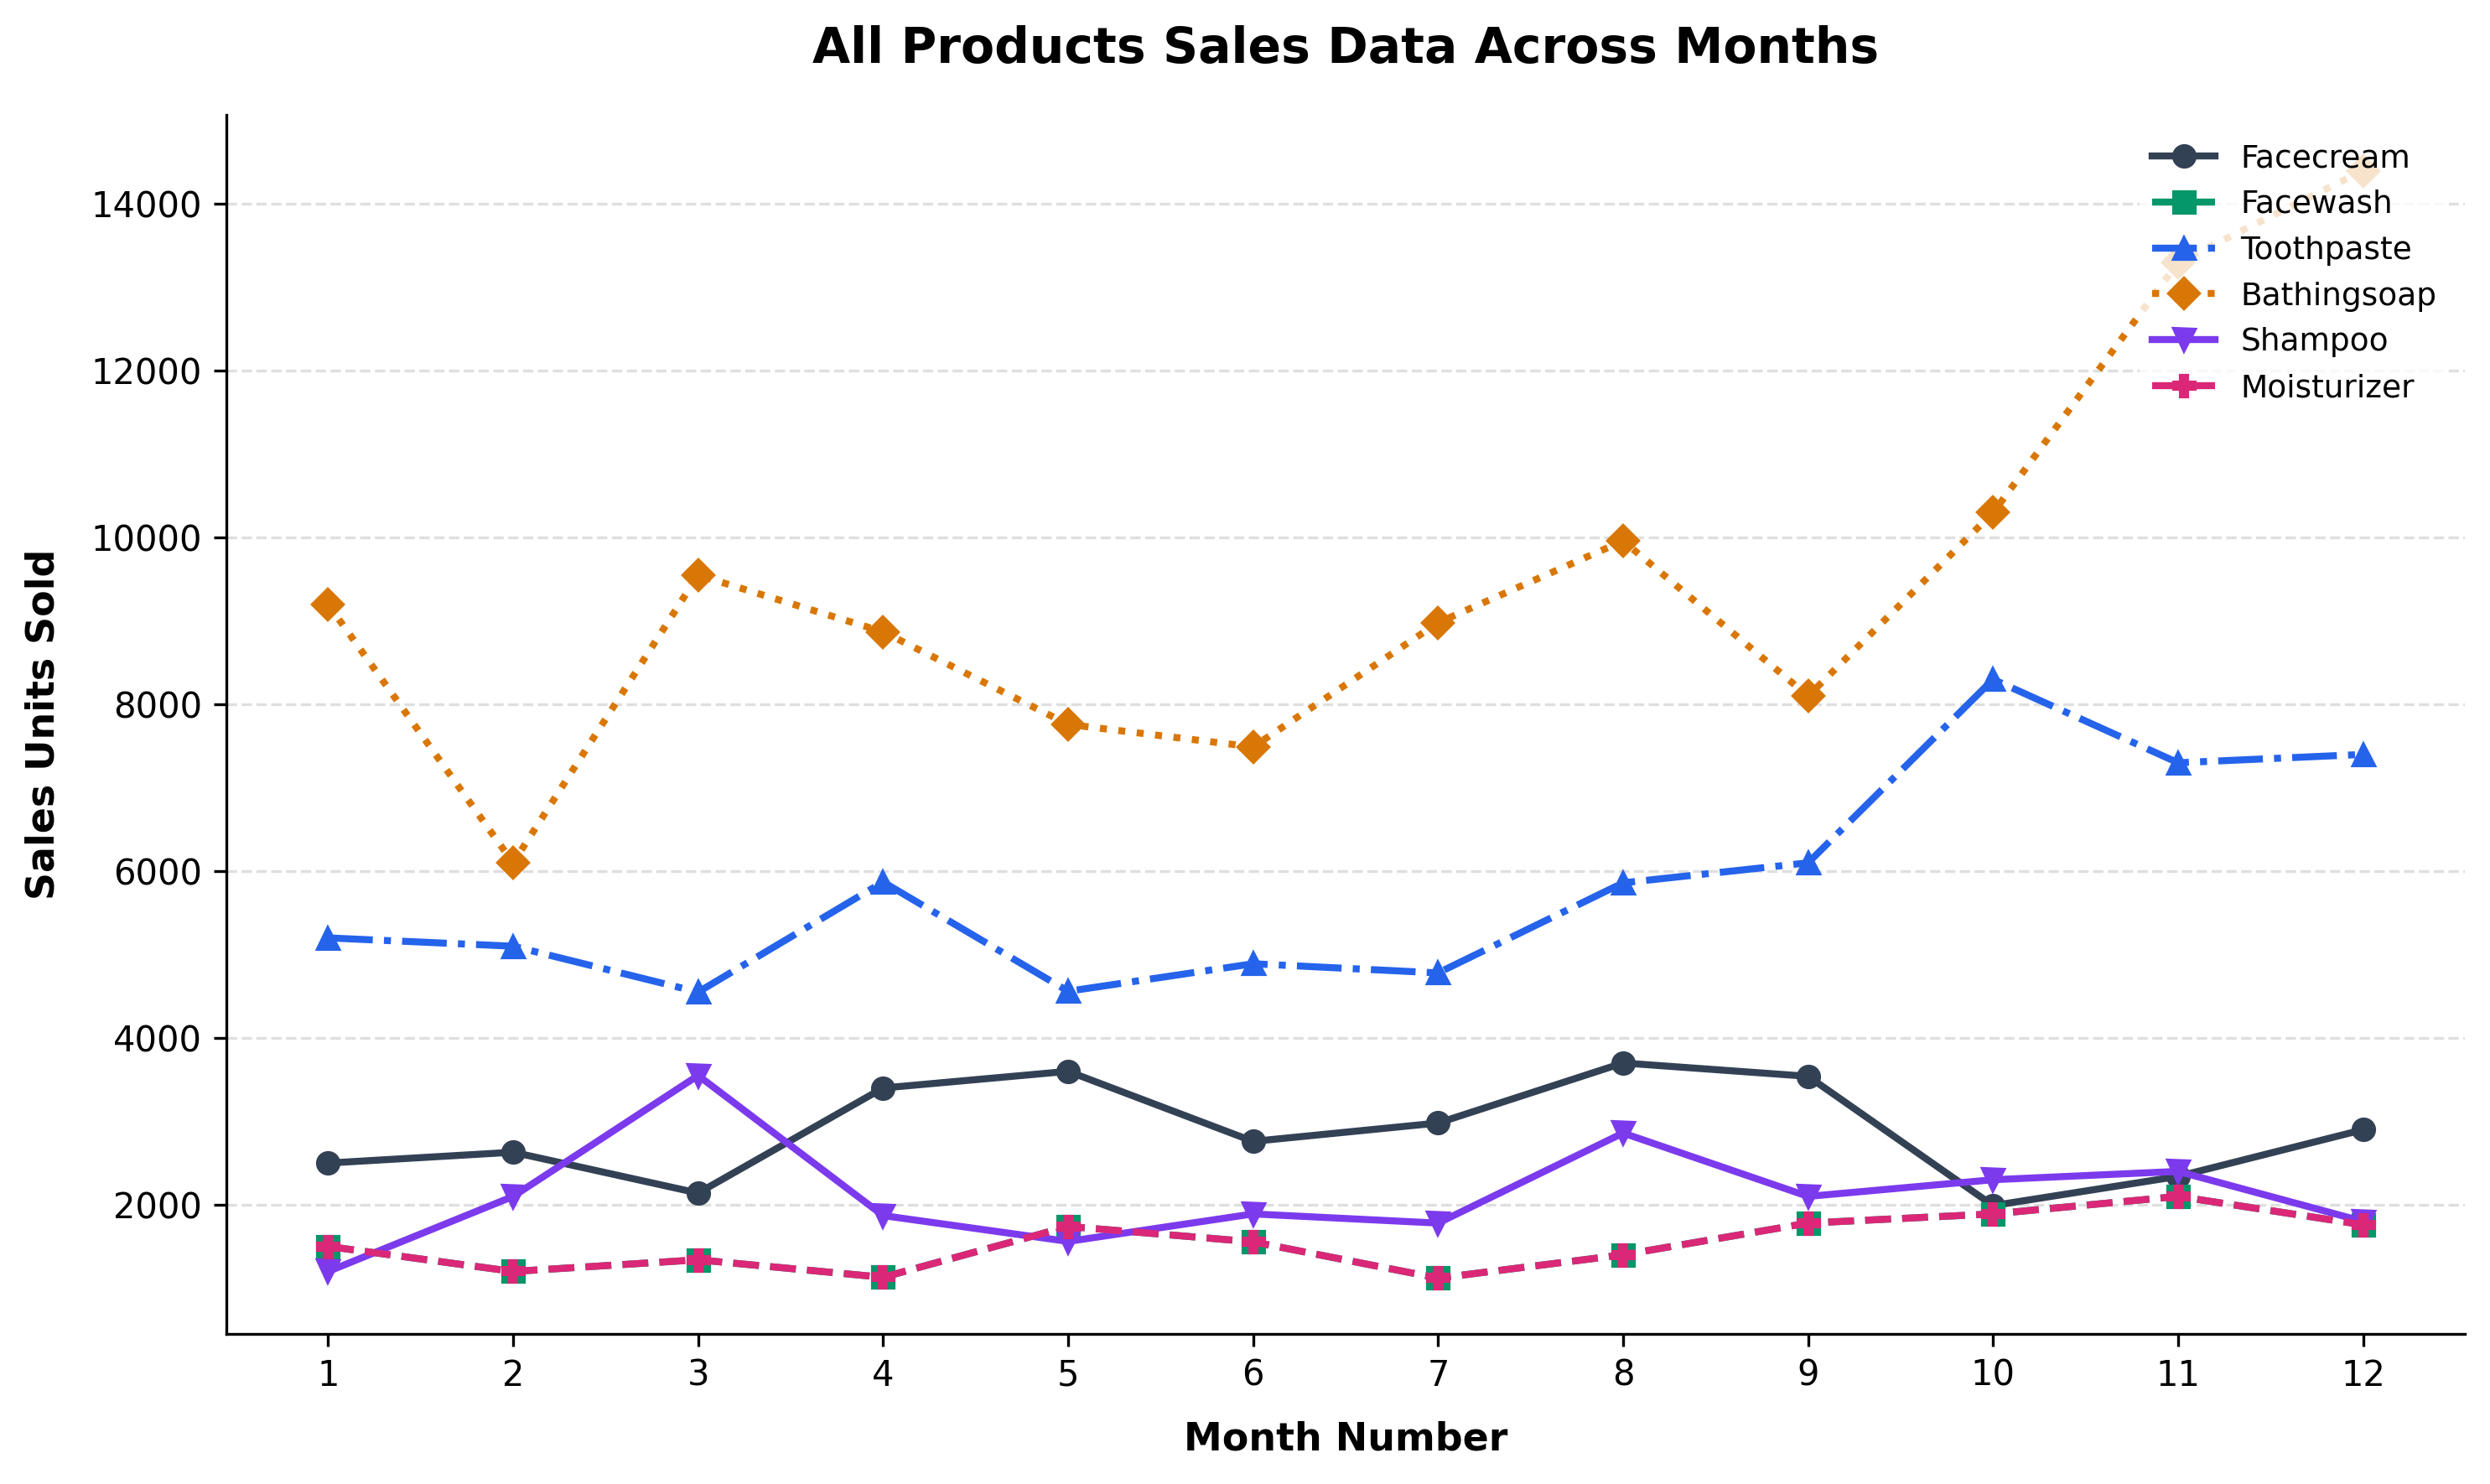

In [86]:
# Create the figure with a suitable size for displaying
# multiple product lines clearly.
#
# dpi=300 creates a high-resolution chart.
plt.figure(
    figsize=(10, 6),
    dpi=300
)


# Store the visual settings for each product in a dictionary.
#
# Each product has its own:
# - color
# - line style
# - marker style
#
# Keeping these settings in one dictionary makes the plotting code
# easier to manage instead of writing a separate plot command
# for every product.
product_styles = {
    "facecream": {
        "color": "#334155",
        "linestyle": "-",
        "marker": "o"
    },

    "facewash": {
        "color": "#059669",
        "linestyle": "--",
        "marker": "s"
    },

    "toothpaste": {
        "color": "#2563EB",
        "linestyle": "-.",
        "marker": "^"
    },

    "bathingsoap": {
        "color": "#D97706",
        "linestyle": ":",
        "marker": "D"
    },

    "shampoo": {
        "color": "#7C3AED",
        "linestyle": "-",
        "marker": "v"
    },

    "moisturizer": {
        "color": "#DB2777",
        "linestyle": "--",
        "marker": "P"
    }
}


# Loop through each product and its visual settings.
#
# .items() gives us two things in every loop:
#
# product → the product name
# style   → the dictionary containing that product's
#           color, line style, and marker
for product, style in product_styles.items():

    # Plot the monthly sales data for the current product.
    #
    # month_number is used on the x-axis.
    # The current product's sales values are used on the y-axis.
    #
    # Each product gets its own style so that the lines
    # can be easily distinguished from one another.
    plt.plot(
        df["month_number"],
        df[product],

        # Convert the product name into a readable label.
        # For example:
        # "facecream" → "Facecream"
        label=product.capitalize(),

        # Get the visual settings from the style dictionary.
        color=style["color"],
        linestyle=style["linestyle"],
        marker=style["marker"],

        linewidth=2,
        markersize=6
    )


# Display normal numbers on the y-axis instead of scientific notation.
# This makes large sales values easier to read.
plt.ticklabel_format(
    style="plain",
    axis="y"
)


# Add a label to the x-axis.
# The x-axis represents the months of the year.
plt.xlabel(
    "Month Number",
    fontsize=11,
    fontweight="bold",
    labelpad=8
)


# Add a label to the y-axis.
# The y-axis represents the number of units sold.
plt.ylabel(
    "Sales Units Sold",
    fontsize=11,
    fontweight="bold",
    labelpad=8
)


# Add a clear title that explains what the chart shows.
# The chart compares the monthly sales trends of all products.
plt.title(
    "All Products Sales Data Across Months",
    fontsize=14,
    fontweight="bold",
    pad=15
)


# Display all available month numbers on the x-axis.
# This makes it easier to identify the sales trend for each month.
plt.xticks(
    df["month_number"]
)


# Add a legend to identify the line belonging to each product.
#
# The legend is placed in the upper-right corner.
# frameon=True keeps a visible background box around the legend.
plt.legend(
    loc="upper right",
    frameon=True,
    facecolor="white",
    edgecolor="none",
    fontsize=9
)


# Add horizontal grid lines to make it easier to compare
# sales values across different months.
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)


# Remove the top and right borders of the chart
# to create a cleaner appearance.
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)


# Automatically adjust the spacing around the chart
# so that the title, labels, and legend do not overlap.
plt.tight_layout()


# Save the chart to a specific location on the computer.
#
# The raw string (r"...") prevents backslashes in the Windows path
# from being treated as special escape characters.
plt.savefig(
    r"C:\Users\Dell\OneDrive\Desktop\My Tasks Notebooks\Day023\plots\problem8_all_products_multiline.png",
    dpi=300,
    bbox_inches="tight"
)


# Save another copy using a relative path.
# This is useful when the project already has a dedicated plots folder.
plt.savefig(
    "plots/problem8_all_products_multiline.png",
    dpi=300,
    bbox_inches="tight"
)


# Display the final chart in the notebook.
plt.show()

### `Problem-9` Show Quarter wise Sales data for all products as multi Bar chart.

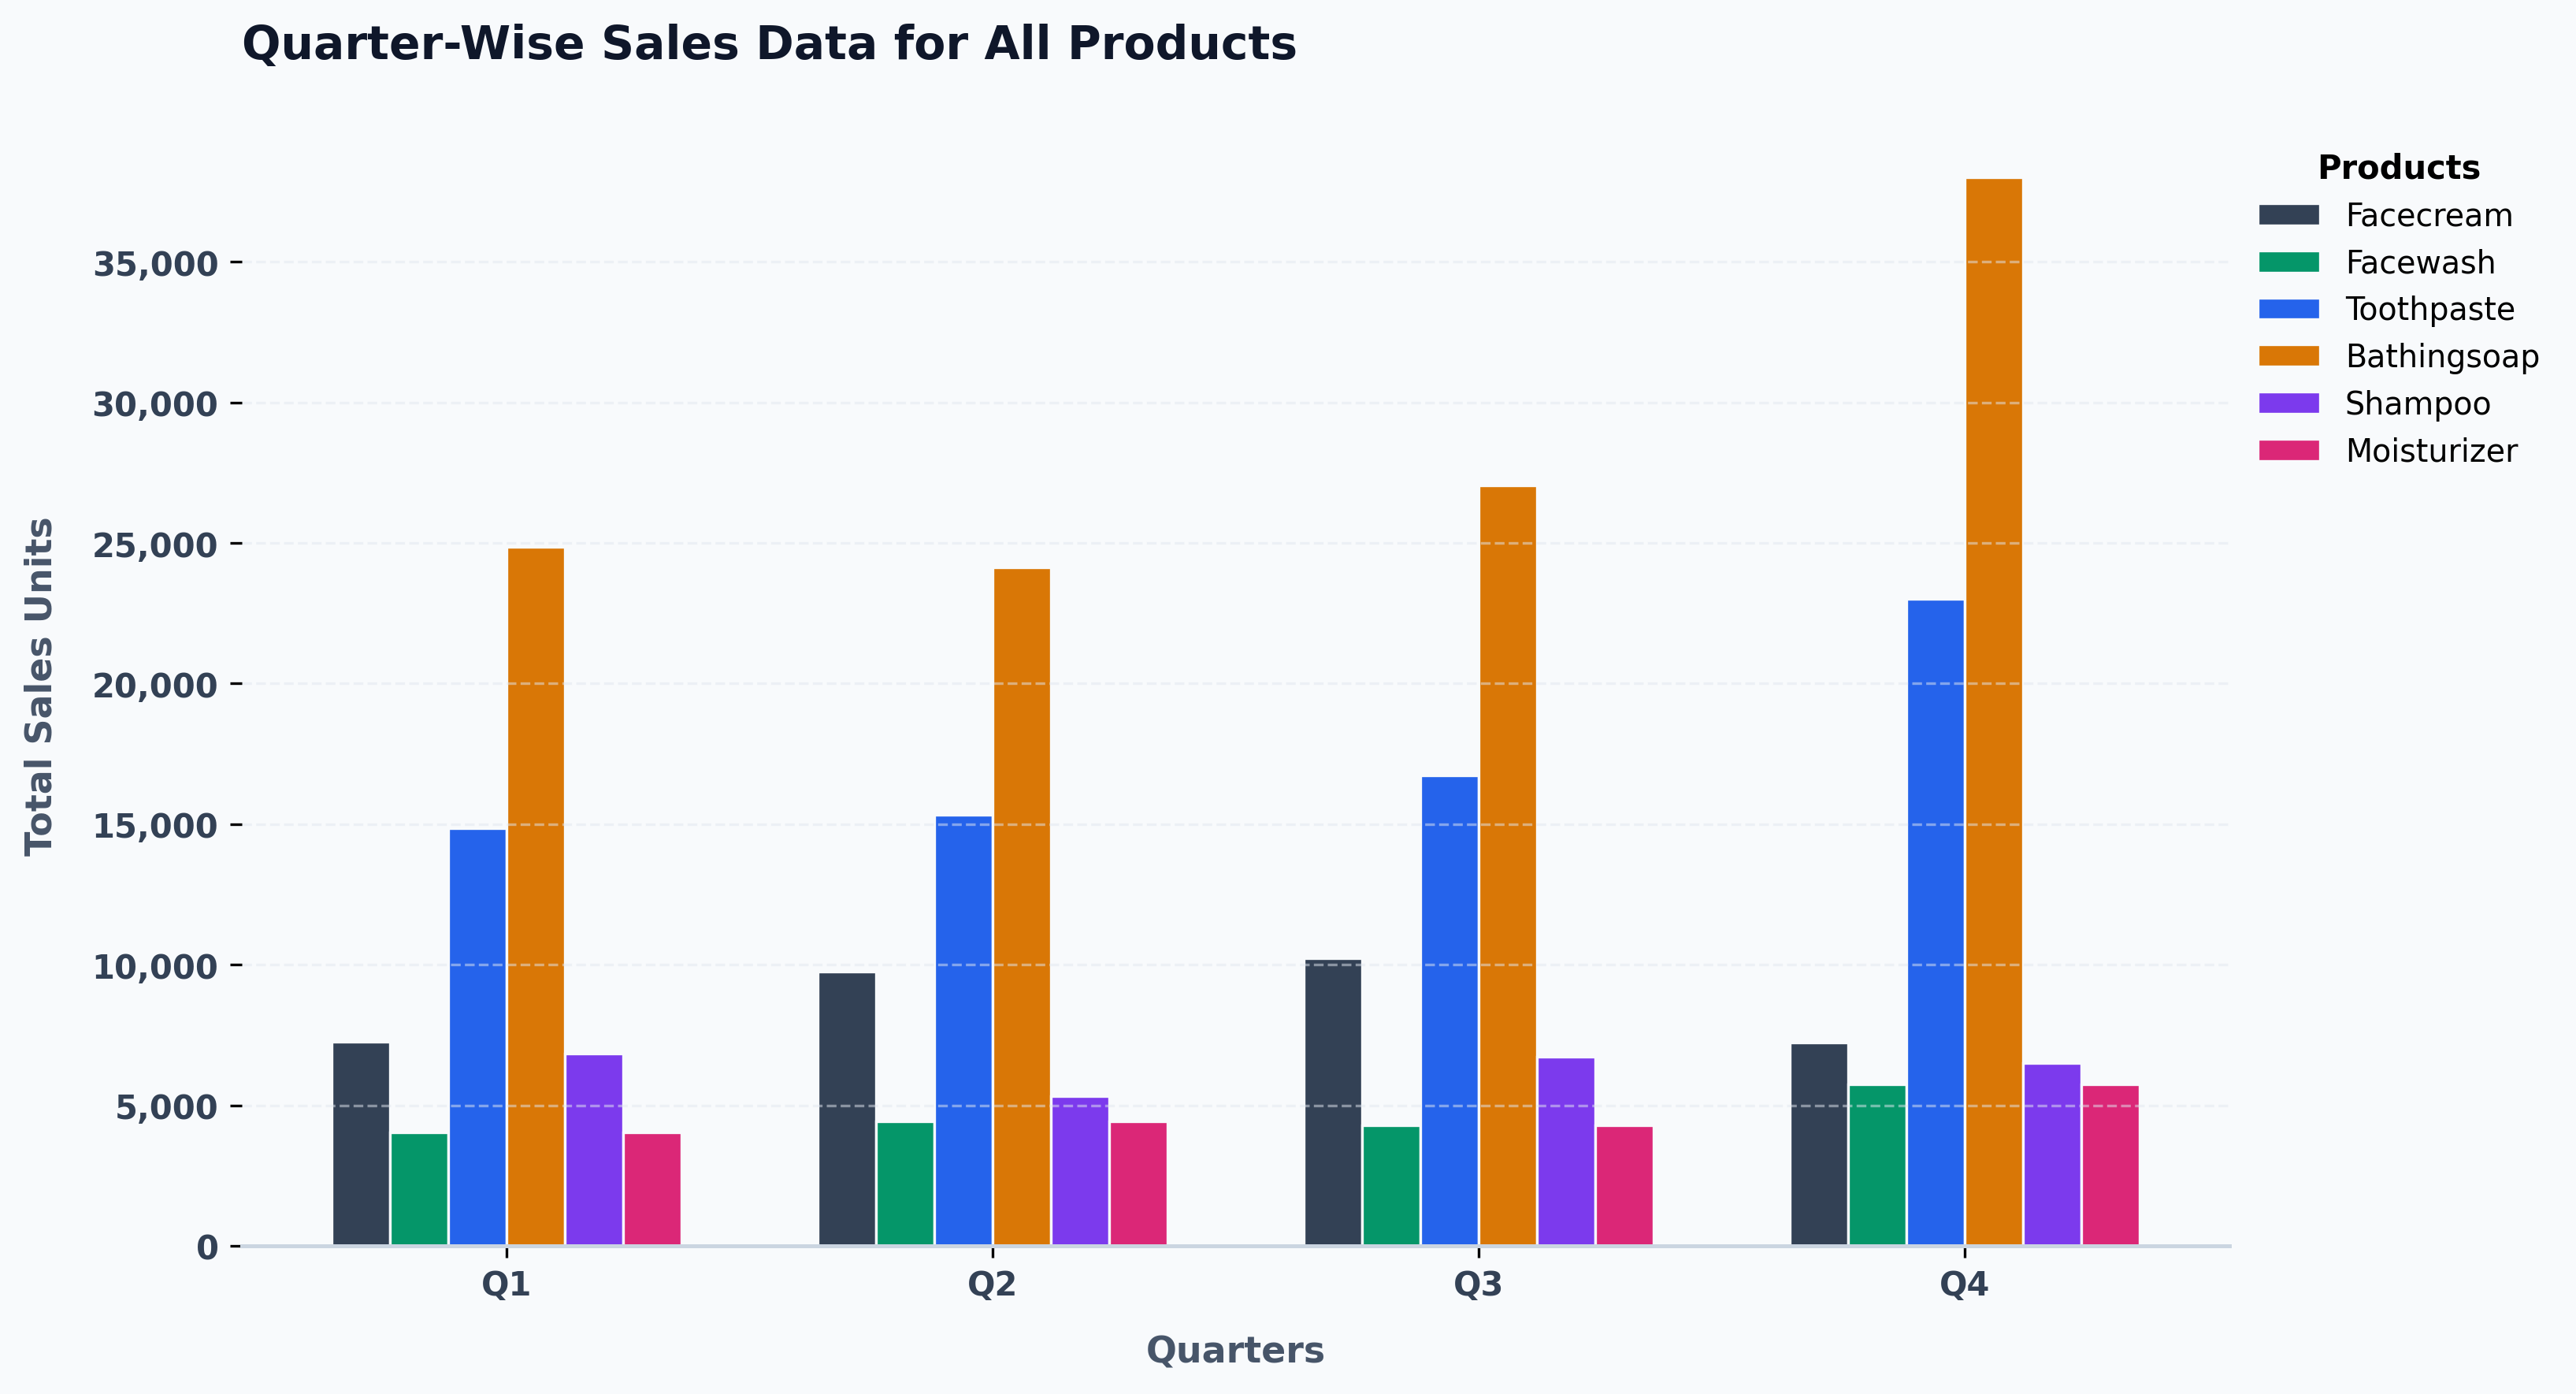

In [87]:
import matplotlib.ticker as ticker
import numpy as np


# Divide the months into four quarters.
#
# Months 1, 2, and 3 belong to Q1.
# Months 4, 5, and 6 belong to Q2.
# Months 7, 8, and 9 belong to Q3.
# Months 10, 11, and 12 belong to Q4.
#
# pd.cut() places each month into the correct interval
# and assigns the corresponding quarter label.
df["quarter"] = pd.cut(
    df["month_number"],
    bins=[0, 3, 6, 9, 12],
    labels=["Q1", "Q2", "Q3", "Q4"]
)


# Store the names of all product columns
# that we want to analyze.
products = [
    "facecream",
    "facewash",
    "toothpaste",
    "bathingsoap",
    "shampoo",
    "moisturizer"
]


# Calculate the total sales of every product for each quarter.
#
# groupby("quarter") combines all months belonging to the same quarter.
# For example:
#
# Q1 → January + February + March
# Q2 → April + May + June
#
# sum() then adds the sales values of each product
# within each quarter.
quarterly_sales = (
    df
    .groupby(
        "quarter",
        observed=False
    )[products]
    .sum()
)


# Create the figure and the axes for the chart.
#
# figsize controls the size of the chart.
# dpi=300 creates a high-resolution figure.
fig, ax = plt.subplots(
    figsize=(11, 6),
    dpi=300
)


# Set a light background color for the complete figure.
fig.patch.set_facecolor("#F8FAFC")


# Set the same background color for the plotting area.
ax.set_facecolor("#F8FAFC")


# Get the quarter labels from the aggregated data.
quarters = quarterly_sales.index


# Create numerical positions for the four quarters.
#
# np.arange(4) creates:
#
# [0, 1, 2, 3]
#
# These positions are used to place the bar groups on the x-axis.
x = np.arange(len(quarters))


# Set the width of each individual bar.
#
# Because six products are being displayed side by side
# within each quarter, a smaller width keeps the bars
# from overlapping.
bar_width = 0.12


# Define a separate color for each product.
# The colors are used in the same order as the products list.
colors = [
    "#334155",
    "#059669",
    "#2563EB",
    "#D97706",
    "#7C3AED",
    "#DB2777"
]


# Create a group of bars for each product.
#
# enumerate() gives us two values:
#
# idx     → the position number of the product
# product → the product name
#
# The index is used to shift each product's bars slightly
# so that all six products appear side by side.
for idx, product in enumerate(products):

    ax.bar(
        x + (idx * bar_width),
        quarterly_sales[product],
        width=bar_width,
        label=product.capitalize(),
        color=colors[idx],
        edgecolor="#F8FAFC",
        linewidth=0.8
    )


# Format the y-axis values with commas
# and remove decimal places.
#
# For example:
#
# 100000.0 → 100,000
ax.yaxis.set_major_formatter(
    ticker.StrMethodFormatter("{x:,.0f}")
)


# Remove unnecessary borders from the top, right, and left sides
# of the chart.
for spine in [
    "top",
    "right",
    "left"
]:
    ax.spines[spine].set_visible(False)


# Keep the bottom border visible as the main x-axis line.
ax.spines["bottom"].set_color("#CBD5E1")


# Make the bottom axis line slightly thicker.
ax.spines["bottom"].set_linewidth(1.2)


# Calculate how far the quarter labels need to move
# so that they appear in the center of each group of bars.
#
# Since the bars start at x and move to the right,
# the center of the complete group is halfway between
# the first and last bar.
center_offset = (
    bar_width * (len(products) - 1)
) / 2


# Place the quarter labels at the center of their bar groups.
#
# x + center_offset moves each label from the first bar's position
# to the middle of the complete group.
plt.xticks(
    x + center_offset,
    quarters,
    fontsize=10,
    fontweight="bold",
    color="#334155"
)


# Customize the appearance of the y-axis labels.
plt.yticks(
    fontsize=10,
    fontweight="bold",
    color="#334155"
)


# Add a clear title that explains what the chart shows.
plt.title(
    "Quarter-Wise Sales Data for All Products",
    fontsize=14,
    fontweight="bold",
    color="#0F172A",
    pad=20,
    loc="left"
)


# Add a label to the x-axis.
# The x-axis represents the four quarters.
plt.xlabel(
    "Quarters",
    fontsize=11,
    fontweight="bold",
    color="#475569",
    labelpad=10
)


# Add a label to the y-axis.
# The y-axis represents the total units sold.
plt.ylabel(
    "Total Sales Units",
    fontsize=11,
    fontweight="bold",
    color="#475569",
    labelpad=10
)


# Add horizontal grid lines to make it easier
# to compare sales values across quarters.
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5,
    color="#E2E8F0"
)


# Place the legend outside the main plotting area.
#
# bbox_to_anchor=(1, 1) moves the legend toward
# the upper-right side of the chart.
#
# The legend identifies the color used for each product.
plt.legend(
    loc="upper left",
    bbox_to_anchor=(1, 1),
    frameon=False,
    fontsize=9.5,
    title="Products",
    title_fontproperties={
        "weight": "bold"
    }
)


# Automatically adjust the spacing around the chart
# so that the labels and the legend do not get cut off.
plt.tight_layout()


# Save the final chart as a high-resolution PNG image.
#
# dpi=300 keeps the image sharp.
# facecolor preserves the light background color.
# edgecolor="none" removes any extra border.
# bbox_inches="tight" includes the legend outside the chart
# without cutting it off.
plt.savefig(
    "plots/problem9_quarterly_sales_multibar.png",
    dpi=300,
    facecolor=fig.get_facecolor(),
    edgecolor="none",
    bbox_inches="tight"
)


# Display the final chart in the notebook.
plt.show()

### `Problem-10` Plot Stacked Bar chart quarter wise for each product.

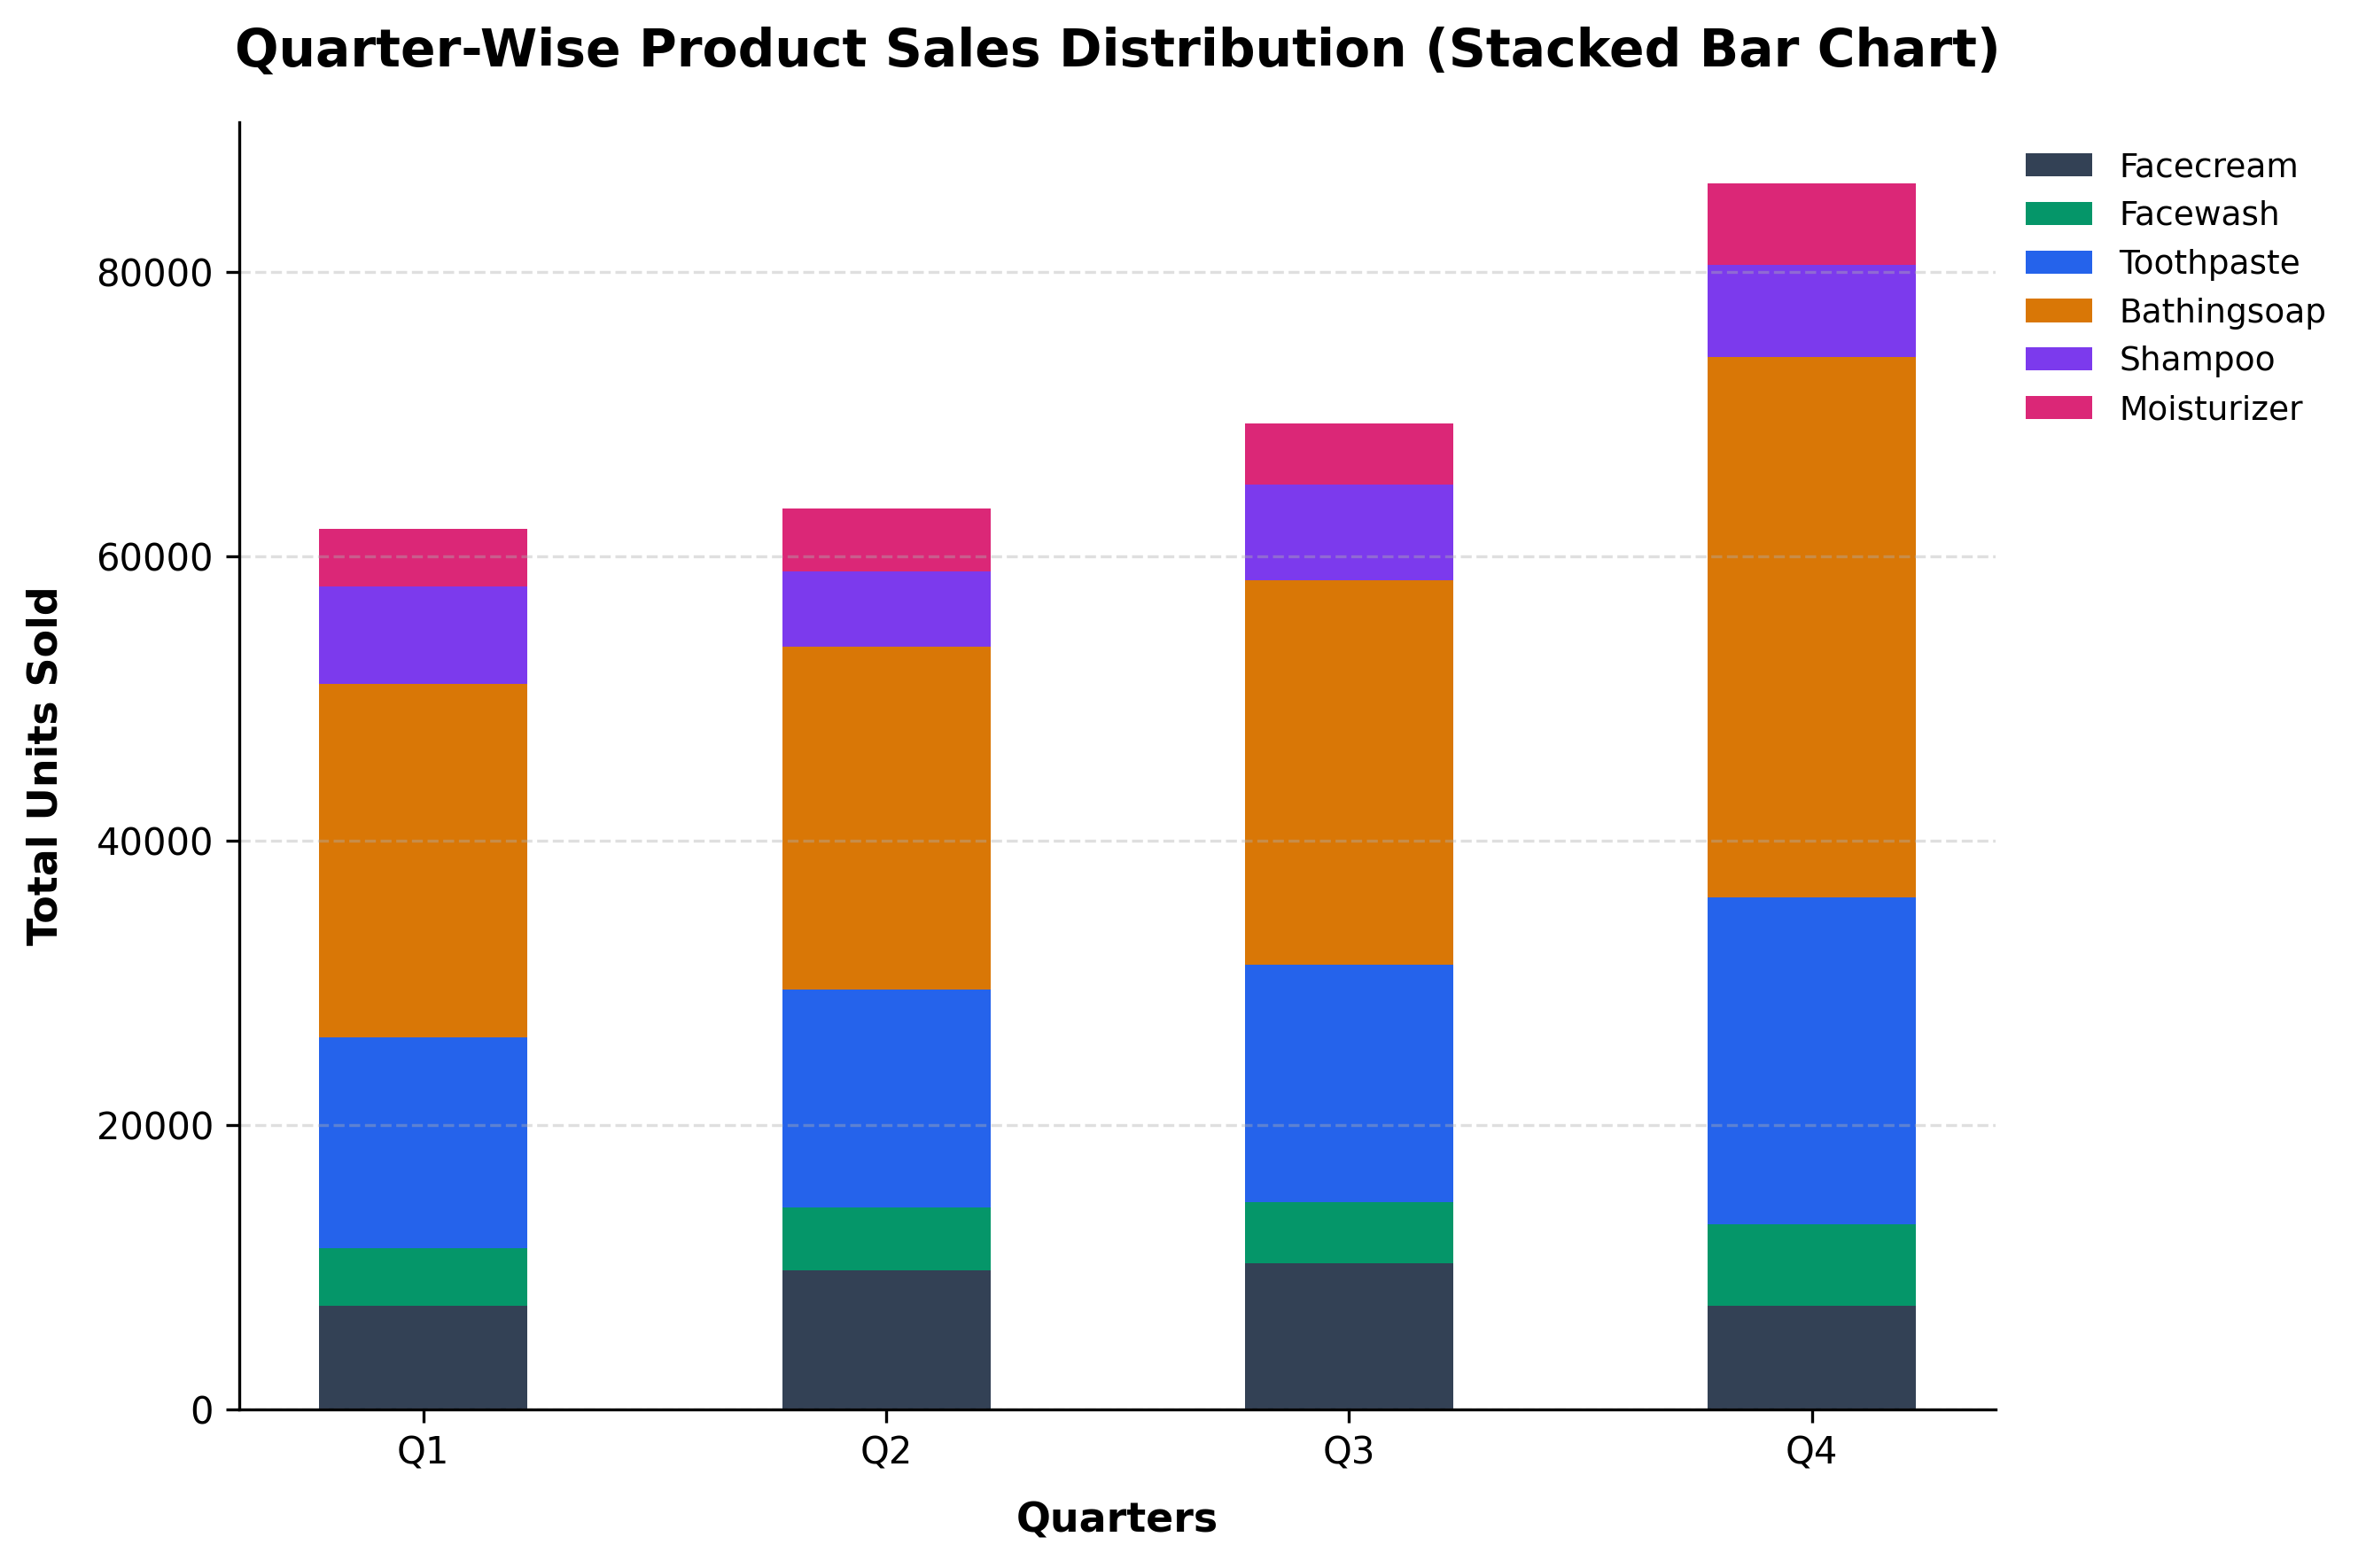

In [88]:
# Create the quarter column only if it does not already exist.
#
# This condition prevents us from creating the same column again
# if the quarter column was already created earlier in the notebook.
if "quarter" not in df.columns:

    # Divide the months into four quarters.
    #
    # Months 1, 2, and 3  → Q1
    # Months 4, 5, and 6  → Q2
    # Months 7, 8, and 9  → Q3
    # Months 10, 11, and 12 → Q4
    df["quarter"] = pd.cut(
        df["month_number"],
        bins=[0, 3, 6, 9, 12],
        labels=["Q1", "Q2", "Q3", "Q4"]
    )


# Store the product names that will be included in the analysis.
products = [
    "facecream",
    "facewash",
    "toothpaste",
    "bathingsoap",
    "shampoo",
    "moisturizer"
]


# Define a separate color for each product.
# The colors are used in the same order as the products list.
colors = [
    "#334155",
    "#059669",
    "#2563EB",
    "#D97706",
    "#7C3AED",
    "#DB2777"
]


# Calculate the total sales of every product for each quarter.
#
# groupby("quarter") combines the monthly data into Q1, Q2, Q3, and Q4.
# sum() adds the sales of each product within every quarter.
quarterly_sales = (
    df
    .groupby(
        "quarter",
        observed=False
    )[products]
    .sum()
)


# Create the figure with a suitable size and high resolution.
plt.figure(
    figsize=(9, 6),
    dpi=300
)


# Start the bottom position at zero.
#
# The first product will start from the x-axis.
# After plotting each product, this value will be updated
# so that the next product can be placed on top of the previous one.
bottom_stack = 0


# Add the products one by one to the same bar.
#
# Each product creates one layer of the stacked bar.
for idx, product in enumerate(products):

    plt.bar(
        quarterly_sales.index,
        quarterly_sales[product],

        # bottom tells Matplotlib where the current layer should start.
        # This places the current product above all previously plotted products.
        bottom=bottom_stack,

        label=product.capitalize(),
        color=colors[idx],
        width=0.45
    )


    # Add the current product's sales to the running total.
    #
    # This updates the starting position for the next product.
    #
    # For example:
    #
    # First product:
    # bottom = 0
    #
    # Second product:
    # bottom = First Product Sales
    #
    # Third product:
    # bottom = First Product Sales + Second Product Sales
    #
    # This is what creates the stacked effect.
    bottom_stack += quarterly_sales[product]


# Display normal numbers on the y-axis
# instead of scientific notation.
plt.ticklabel_format(
    style="plain",
    axis="y"
)


# Add a label to the x-axis.
# The x-axis represents the four quarters.
plt.xlabel(
    "Quarters",
    fontsize=11,
    fontweight="bold",
    labelpad=8
)


# Add a label to the y-axis.
# The y-axis represents the total number of units sold.
plt.ylabel(
    "Total Units Sold",
    fontsize=11,
    fontweight="bold",
    labelpad=8
)


# Add a clear title that explains what the stacked bar chart shows.
plt.title(
    "Quarter-Wise Product Sales Distribution (Stacked Bar Chart)",
    fontsize=14,
    fontweight="bold",
    pad=15
)


# Place the legend outside the main plotting area.
# The legend identifies the color of each product.
plt.legend(
    loc="upper left",
    bbox_to_anchor=(1, 1),
    frameon=False,
    fontsize=9
)


# Add horizontal grid lines to make the total heights of the bars
# easier to compare across quarters.
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)


# Remove the top and right borders for a cleaner appearance.
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)


# Automatically adjust the spacing around the chart
# so that the title, labels, and legend are not cut off.
plt.tight_layout()


# Save the final stacked bar chart as a high-resolution PNG image.
#
# dpi=300 keeps the image sharp.
# bbox_inches="tight" includes the legend outside the chart
# without cutting it off.
plt.savefig(
    "plots/problem10_quarterly_sales_stackedbar.png",
    dpi=300,
    bbox_inches="tight"
)


# Display the final chart in the notebook.
plt.show()